# Gigs Senior Data Analyst Challenge

Welcome to the Gigs data analyst take-home challenge! This notebook will help you get started with analyzing our connectivity usage data.

## About the Data

You'll be working with three main datasets:
- **Usage Data**: Detailed usage per subscription period (~100K+ records)
- **Plan Events**: Plan configuration and pricing history
- **Projects**: Project metadata

## Setup Instructions

Run the cells below to set up your environment and load the data into DuckDB.

In [218]:
# Import required libraries
import duckdb
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
print("✅ Libraries imported successfully!")
# Load JupySQL extension and configure
%load_ext sql

# Configure JupySQL for better output
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False

print("✅ JupySQL configured!")

✅ Libraries imported successfully!
The sql extension is already loaded. To reload it, use:
  %reload_ext sql
✅ JupySQL configured!


In [219]:
# Connect to DuckDB
conn = duckdb.connect('gigs-analytics.db')
%sql conn --alias duckdb

print("✅ Connected to DuckDB database: gigs-analytics.db")

✅ Connected to DuckDB database: gigs-analytics.db


In [220]:
%%sql
-- Load data into DuckDB tables
CREATE OR REPLACE TABLE usage_data AS 
SELECT * FROM 'data/usage_by_subscription_period.csv';

CREATE OR REPLACE TABLE plan_events AS 
SELECT * FROM 'data/plan_change_events.csv';

CREATE OR REPLACE TABLE projects AS 
SELECT * FROM 'data/projects.csv';

,Count
0,3


In [221]:
%%sql
-- Verify data loading
select 
  'usage_data' as table_name, 
  count(*) as row_count,
  count(distinct subscription_id) as unique_subscriptions
from usage_data
union all
select 
  'plan_events' as table_name, 
  count(*) as row_count,
  count(distinct plan_id) as unique_plans
from plan_events
union all
select 
  'projects' as table_name, 
  count(*) as row_count,
  count(distinct project_id__hashed) as unique_projects
from projects;

,table_name,row_count,unique_subscriptions
0,usage_data,53565,8457
1,plan_events,209,36
2,projects,3,3


## Your Analysis Starts Here!

Now you have everything set up. Use the cells below to start your analysis.

### Tips:
- Use `%%sql` for multi-line SQL queries
- Use `%%sql variable_name <<` to store results in a Python variable
- Combine SQL with Python/Pandas for advanced analysis
- Feel free to use any visualisation library you feel comfortable with


# Part 1: Data Exploration & Overview

#Let's first understand the structure and quality of our data before diving into the analysis.


In [222]:
%%sql  <<
-- Overview of projects and their characteristics
SELECT 
    p.project_id__hashed,
    p.organization_name,
    p.project_type,
    p.device_type,
    COUNT(DISTINCT u.subscription_id) as total_subscriptions,
    COUNT(DISTINCT u.plan_id) as plans_used,
    MIN(u.subscription_period_start) as first_activity,
    MAX(u.subscription_period_end) as last_activity
FROM projects p
LEFT JOIN usage_data u ON p.project_id__hashed = u.project_id__hashed
GROUP BY ALL
ORDER BY first_activity


,project_id__hashed,organization_name,project_type,device_type,total_subscriptions,plans_used,first_activity,last_activity
0,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,ACME Phone,Connect,Phones,6737,3,2024-01-21,2025-06-17
1,2aeca1a6c1ecf52b28b7f7646b6fb90563a417ee3e5dc3...,SmartDevices Inc.,Connect,Wearables,986,3,2025-03-04,2025-06-17
2,dace2786aee7632e61757b320a6fe5bff37a2e742fe558...,People Mobile,API,Phones,734,6,2025-04-01,2025-06-17



# Part 2: How Much Data Does a Subscription Typically Consume?

#We'll analyze data consumption patterns across all subscriptions to understand typical usage.


In [223]:
%%sql overall_data_usage <<
-- Overall data usage statistics per subscription period
SELECT 
    'All Subscriptions' as segment,
    COUNT(*) as total_periods,
    COUNT(DISTINCT subscription_id) as unique_subscriptions,
    
    -- Central tendency
    ROUND(AVG(cumulative_data_usage_megabyte), 2) as avg_data_mb,
    ROUND(MEDIAN(cumulative_data_usage_megabyte), 2) as median_data_mb,
    
    -- Distribution
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p25_data_mb,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p75_data_mb,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p90_data_mb,
    ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p95_data_mb,
    
    -- Extremes
    ROUND(MIN(cumulative_data_usage_megabyte), 2) as min_data_mb,
    ROUND(MAX(cumulative_data_usage_megabyte), 2) as max_data_mb,
    
    -- Zero usage
    SUM(CASE WHEN cumulative_data_usage_megabyte = 0 THEN 1 ELSE 0 END) as zero_usage_periods,
    ROUND(100.0 * SUM(CASE WHEN cumulative_data_usage_megabyte = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as zero_usage_pct
FROM usage_data


In [224]:
overall_data_usage

,segment,total_periods,unique_subscriptions,avg_data_mb,median_data_mb,p25_data_mb,p75_data_mb,p90_data_mb,p95_data_mb,min_data_mb,max_data_mb,zero_usage_periods,zero_usage_pct
0,All Subscriptions,53565,8457,1413.41,134.43,6.04,523.15,1667.04,4745.46,0.0,282946.54,11359.0,21.2


In [225]:
%%sql data_usage_by_project <<
-- Data usage statistics broken down by project
SELECT 
    p.organization_name,
    p.project_type,
    p.device_type,
    COUNT(*) as total_periods,
    COUNT(DISTINCT u.subscription_id) as unique_subscriptions,
    
    -- Central tendency
    ROUND(AVG(u.cumulative_data_usage_megabyte), 2) as avg_data_mb,
    ROUND(MEDIAN(u.cumulative_data_usage_megabyte), 2) as median_data_mb,
    
    -- Distribution
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY u.cumulative_data_usage_megabyte), 2) as p25_data_mb,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY u.cumulative_data_usage_megabyte), 2) as p75_data_mb,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY u.cumulative_data_usage_megabyte), 2) as p90_data_mb,
    
    -- Zero usage rate
    ROUND(100.0 * SUM(CASE WHEN u.cumulative_data_usage_megabyte = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as zero_usage_pct
FROM usage_data u
JOIN projects p ON u.project_id__hashed = p.project_id__hashed
GROUP BY ALL
ORDER BY avg_data_mb DESC


In [226]:
data_usage_by_project

,organization_name,project_type,device_type,total_periods,unique_subscriptions,avg_data_mb,median_data_mb,p25_data_mb,p75_data_mb,p90_data_mb,zero_usage_pct
0,People Mobile,API,Phones,823,734,20623.34,4702.65,0.00,25690.37,66367.89,28.1
1,SmartDevices Inc.,Connect,Wearables,1474,986,2524.40,669.48,48.79,2972.77,6897.09,17.6
2,ACME Phone,Connect,Phones,51268,6737,1073.10,129.27,6.05,469.33,1377.94,21.2


In [227]:
%%sql usage_data_w_projects <<
Select * from usage_data u JOIN projects p ON u.project_id__hashed = p.project_id__hashed

In [228]:
%%sql plan_events <<
Select * from plan_events


In [229]:
plan_events.plan_name.unique()

array(['Unlimited Data Plan', 'Unlimited Plan', 'Ultra Unlimited',
       'Unlimited Ultra', 'SMS Only Plan', 'No Allowances Plan',
       'Easy Plan', 'Plus Plan', '5GB Test Plan', 'Basic Plan',
       '5GB Plan', '5GB'], dtype=object)

In [230]:
# Check if distinct_months counts are inflated due to year changes
import pandas as pd

# Get unique year-month combinations by organization
if 'period_start_month' in usage_data_w_projects.columns:
    monthyear = usage_data_w_projects.groupby('organization_name')['period_start_month'].unique()
    distinct_months = usage_data_w_projects.groupby('organization_name')['period_start_month'].nunique()
else:
    # Derive year-month from dates. This is robust to year change.
    def get_year_month(s):
        dates = pd.to_datetime(s)
        return set((d.year, d.month) for d in dates)
    monthyear = usage_data_w_projects.groupby('organization_name')['subscription_period_start'].apply(get_year_month)
    distinct_months = monthyear.apply(len)

subscription_counts = usage_data_w_projects.groupby('organization_name')['subscription_id'].nunique()

result = pd.DataFrame({
    'unique_subscriptions': subscription_counts,
    'distinct_months_year': distinct_months
})

# For each org, show the months used for checking
for org in ['ACME Phone', 'People Mobile', 'SmartDevices Inc.']:
    months = monthyear[org]
    print(f"{org} unique year-months:", sorted(list(months)))
result

ACME Phone unique year-months: [(2024, 1), (2024, 2), (2024, 3), (2024, 4), (2024, 5), (2024, 6), (2024, 7), (2024, 8), (2024, 9), (2024, 10), (2024, 11), (2024, 12), (2025, 1), (2025, 2), (2025, 3), (2025, 4), (2025, 5), (2025, 6)]
People Mobile unique year-months: [(2025, 4), (2025, 5), (2025, 6)]
SmartDevices Inc. unique year-months: [(2025, 3), (2025, 4), (2025, 5), (2025, 6)]


,unique_subscriptions,distinct_months_year
organization_name,,
ACME Phone,6737,18
People Mobile,734,3
SmartDevices Inc.,986,4


In [231]:
%%sql usage_distribution <<
-- Get data usage distribution for visualization
SELECT 
    CASE 
        WHEN cumulative_data_usage_megabyte = 0 THEN '0 MB (No usage)'
        WHEN cumulative_data_usage_megabyte <= 100 THEN '1-100 MB'
        WHEN cumulative_data_usage_megabyte <= 500 THEN '101-500 MB'
        WHEN cumulative_data_usage_megabyte <= 1000 THEN '501-1000 MB'
        WHEN cumulative_data_usage_megabyte <= 2000 THEN '1-2 GB'
        WHEN cumulative_data_usage_megabyte <= 5000 THEN '2-5 GB'
        WHEN cumulative_data_usage_megabyte <= 10000 THEN '5-10 GB'
        ELSE '10+ GB'
    END as usage_bucket,
    CASE 
        WHEN cumulative_data_usage_megabyte = 0 THEN 1
        WHEN cumulative_data_usage_megabyte <= 100 THEN 2
        WHEN cumulative_data_usage_megabyte <= 500 THEN 3
        WHEN cumulative_data_usage_megabyte <= 1000 THEN 4
        WHEN cumulative_data_usage_megabyte <= 2000 THEN 5
        WHEN cumulative_data_usage_megabyte <= 5000 THEN 6
        WHEN cumulative_data_usage_megabyte <= 10000 THEN 7
        ELSE 8
    END as bucket_order,
    COUNT(*) as period_count,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 1) as percentage
FROM usage_data
GROUP BY ALL
ORDER BY bucket_order


In [232]:
%%sql usage_distribution_by_project <<
-- Get data usage distribution by project for visualization
SELECT 
    p.organization_name,
    CASE 
        WHEN u.cumulative_data_usage_megabyte = 0 THEN '0 MB (No usage)'
        WHEN u.cumulative_data_usage_megabyte <= 100 THEN '1-100 MB'
        WHEN u.cumulative_data_usage_megabyte <= 500 THEN '101-500 MB'
        WHEN u.cumulative_data_usage_megabyte <= 1000 THEN '501-1000 MB'
        WHEN u.cumulative_data_usage_megabyte <= 2000 THEN '1-2 GB'
        WHEN u.cumulative_data_usage_megabyte <= 5000 THEN '2-5 GB'
        WHEN u.cumulative_data_usage_megabyte <= 10000 THEN '5-10 GB'
        ELSE '10+ GB'
    END as usage_bucket,
    CASE 
        WHEN u.cumulative_data_usage_megabyte = 0 THEN 1
        WHEN u.cumulative_data_usage_megabyte <= 100 THEN 2
        WHEN u.cumulative_data_usage_megabyte <= 500 THEN 3
        WHEN u.cumulative_data_usage_megabyte <= 1000 THEN 4
        WHEN u.cumulative_data_usage_megabyte <= 2000 THEN 5
        WHEN u.cumulative_data_usage_megabyte <= 5000 THEN 6
        WHEN u.cumulative_data_usage_megabyte <= 10000 THEN 7
        ELSE 8
    END as bucket_order,
    COUNT(*) as period_count,
    -- Percentage within each project
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(PARTITION BY p.organization_name), 1) as percentage
FROM usage_data u
JOIN projects p ON u.project_id__hashed = p.project_id__hashed
GROUP BY 1,2,3
ORDER BY p.organization_name, bucket_order


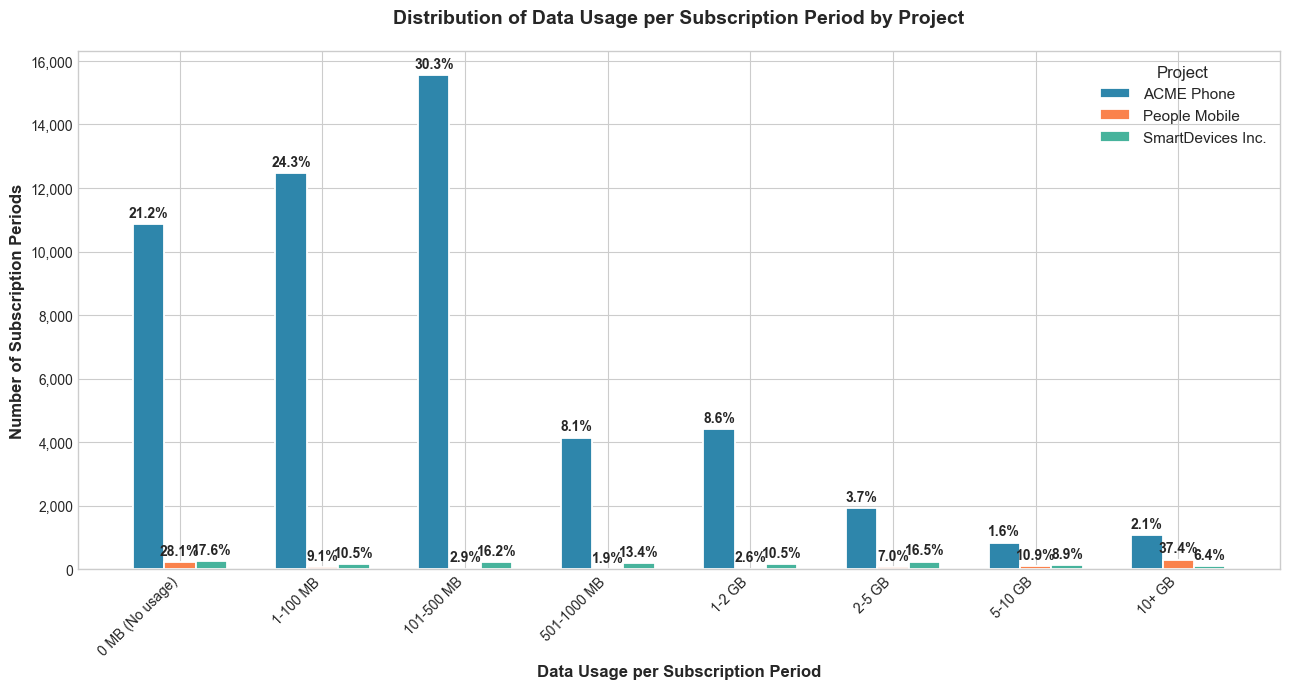

In [233]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Set color palette for projects (three in your analysis)
project_palette = {
    'ACME Phone': '#2E86AB',
    'People Mobile': '#FA824C',
    'SmartDevices Inc.': '#47B39C'
}

fig, ax = plt.subplots(figsize=(13, 7))

# Get unique usage buckets, force order to match SQL
bucket_order = [
    '0 MB (No usage)', '1-100 MB', '101-500 MB', '501-1000 MB', 
    '1-2 GB', '2-5 GB', '5-10 GB', '10+ GB'
]

# Pivot data to stacked for each project in hue
width = 0.22
proj_names = list(usage_distribution_by_project['organization_name'].unique())
x = range(len(bucket_order))

for i, project in enumerate(proj_names):
    df_proj = usage_distribution_by_project[usage_distribution_by_project['organization_name'] == project]
    # Ensure bucket order
    df_plot = df_proj.set_index('usage_bucket').reindex(bucket_order).reset_index()
    positions = [xi + (i - 1)*width for xi in x]
    bars = ax.bar(
        positions,
        df_plot['period_count'],
        width=width,
        label=project,
        color=project_palette.get(project, None),
        edgecolor='white',
        linewidth=1.3
    )
    # Add percentage labels above bars
    for bar, pct in zip(bars, df_plot['percentage']):
        height = bar.get_height()
        if not pd.isnull(height) and height > 0:
            ax.annotate(f'{pct}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

# X-ticks in group at bucket center
ax.set_xticks(x)
ax.set_xticklabels(bucket_order, rotation=45, ha='right')

ax.set_xlabel('Data Usage per Subscription Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Subscription Periods', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Data Usage per Subscription Period by Project', fontsize=14, fontweight='bold', pad=20)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.legend(title='Project', fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()


## 📊 Key Insights: Data Usage Distribution by Project

### 1. ACME Phone (51,268 periods) - Light Usage, Phone-Centric

| Bucket | Count | % |
|--------|-------|---|
| 0 MB (No usage) | 10,869 | 21.2% |
| 1-100 MB | 12,460 | 24.3% |
| 101-500 MB | 15,543 | 30.3% |
| 501 MB+ | 12,396 | 24.1% |

**Insight:** ~**75% of ACME Phone subscribers use less than 500 MB per period**. The distribution is heavily left-skewed, suggesting this is a **utility/light-use consumer phone market**. The high proportion of very light users (1-100 MB) combined with 21% zero usage may indicate:
- Backup/secondary lines
- Voice/SMS-primary use cases
- Potentially churning or dormant subscribers

---

### 2. People Mobile (823 periods) - Bimodal "Power Users or Nothing"

| Bucket | Count | % |
|--------|-------|---|
| 0 MB (No usage) | 231 | **28.1%** |
| 1-500 MB | 99 | 12.0% |
| 500 MB - 5 GB | 95 | 11.5% |
| 5-10 GB | 90 | 10.9% |
| **10+ GB** | 308 | **37.4%** |

**Insight:** This is a **striking bimodal distribution** - subscribers either use **nothing (28%)** or are **heavy data consumers (37% use 10+ GB)**. With an average of **20.6 GB** and median of **4.7 GB**, this is clearly a **data-intensive user base**. This suggests:
- API integration enables power users (streamers, tethering, IoT gateways?)
- The zero-usage group may be testing/dev accounts or failed activations
- **Plan allowances may be underestimating actual needs** - most active users exceed typical 5 GB plans

---

### 3. SmartDevices Inc. (1,474 periods) - Balanced Wearable Usage

| Bucket | Count | % |
|--------|-------|---|
| 0 MB | 259 | 17.6% |
| 1-100 MB | 155 | 10.5% |
| 101-500 MB | 239 | 16.2% |
| 500 MB - 2 GB | 352 | 23.9% |
| 2-10 GB | 374 | 25.4% |
| 10+ GB | 95 | 6.4% |

**Insight:** The **most evenly distributed** usage pattern. Wearables show consistent, moderate data consumption (median 669 MB). Lower zero-usage rate (17.6%) suggests **better activation/engagement** for wearables vs. phones. The absence of a heavy-user tail makes sense - wearables typically lack video streaming use cases.

---

## 🎯 Strategic Implications

| Metric | ACME Phone | People Mobile | SmartDevices |
|--------|------------|---------------|--------------|
| Zero usage % | 21.2% | **28.1%** ⚠️ | 17.6% ✅ |
| Median usage | 129 MB | **4,703 MB** | 669 MB |
| Heavy users (10+ GB) | 2.1% | **37.4%** 🔥 | 6.4% |

**Recommendations:**
1. **People Mobile** needs investigation into the high zero-usage rate - are these failed activations or intentional? Also consider whether plan pricing captures the value of heavy users.
2. **ACME Phone** could benefit from tiered plans with smaller data allowances at lower prices for the 75% using <500 MB.
3. **SmartDevices Inc.** shows healthiest engagement - This can be used as baseline for expected wearable usage patterns.

## 2.1 Comprehensive Consumption Analysis by Subscription Period Duration

A critical factor in understanding subscription consumption is the **duration of the subscription period**. Subscriptions with longer active periods naturally accumulate more usage, so we need to analyze consumption relative to how many days the subscription has been active.

This section:
1. Analyzes the distribution of subscription period lengths
2. Breaks down consumption (data, voice, SMS) by period duration categories
3. Provides normalized daily consumption metrics
4. Summarizes typical consumption patterns with ranges


In [234]:
%%sql period_lengths <<
-- Analyze the distribution of subscription period lengths
SELECT 
    -- Calculate days active in subscription period
    DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE) as days_active,
    COUNT(*) as period_count,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) as pct_of_total
FROM usage_data
GROUP BY days_active
ORDER BY days_active


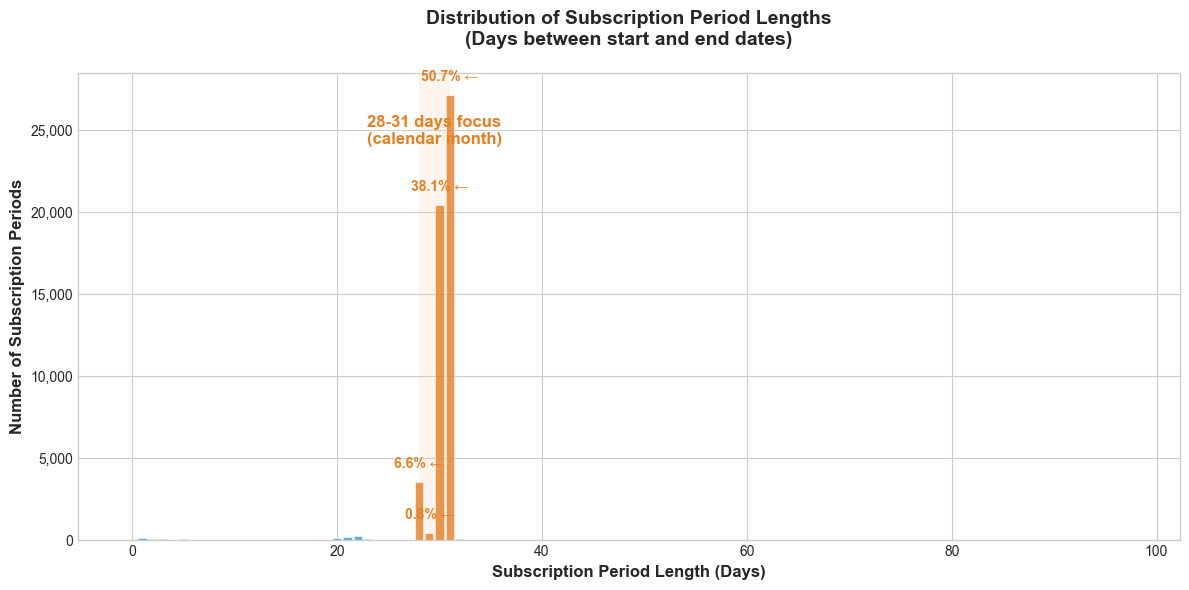

📊 Subscription Period Length Summary:
   • Most common period lengths: [31, 30, 28] days
   • Range of period lengths: 0 to 97 days
   • 🚩 Periods between 28-31 days (monthly emphasis): 51541 periods (96.2% of all)


In [235]:
# Visualize the distribution of subscription period lengths
fig, ax = plt.subplots(figsize=(12, 6))

# Highlight bars in the 28-31 day range
highlight_color = '#E67E22'
default_color = '#3498DB'
bar_colors = [
    highlight_color if 28 <= days <= 31 else default_color
    for days in period_lengths['days_active']
]

bars = ax.bar(period_lengths['days_active'], period_lengths['period_count'],
              color=bar_colors, edgecolor='white', linewidth=0.5, alpha=0.8)

# Annotate significant buckets and emphasize 28-31 specifically
for bar, days, pct in zip(bars, period_lengths['days_active'], period_lengths['pct_of_total']):
    height = bar.get_height()
    annotation = f'{pct:.1f}%'
    if 28 <= days <= 31:
        annotation += ' ←'
        ax.annotate(
            annotation,
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 8), textcoords="offset points",
            ha='center', va='bottom', fontsize=10, fontweight='bold', color=highlight_color
        )
    elif pct >= 5:
        ax.annotate(
            annotation,
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3), textcoords="offset points",
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

# Visual highlight for the 28-31 day band
ax.axvspan(28, 31, facecolor=highlight_color, alpha=0.08, zorder=0)
ax.text(
    29.5, ax.get_ylim()[1]*0.84, '28-31 days focus\n(calendar month)',
    ha='center', va='bottom', fontsize=12, color=highlight_color, fontweight='bold'
)

ax.set_xlabel('Subscription Period Length (Days)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Subscription Periods', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Subscription Period Lengths\n(Days between start and end dates)', fontsize=14, fontweight='bold', pad=20)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

# Enhanced summary statistics emphasizing 28-31 days
range_28_31 = period_lengths.loc[period_lengths['days_active'].between(28, 31)]
pct_28_31 = range_28_31['period_count'].sum() / period_lengths['period_count'].sum() * 100

print("📊 Subscription Period Length Summary:")
print(f"   • Most common period lengths: {period_lengths.nlargest(3, 'period_count')['days_active'].tolist()} days")
print(f"   • Range of period lengths: {period_lengths['days_active'].min()} to {period_lengths['days_active'].max()} days")
print(f"   • 🚩 Periods between 28-31 days (monthly emphasis): {range_28_31['period_count'].sum()} periods ({pct_28_31:.1f}% of all)")


In [236]:
%%sql consumption_by_duration <<
-- Comprehensive consumption analysis by subscription period duration
-- Includes data, voice, and SMS with both total and daily-normalized metrics
SELECT 
    CASE 
        WHEN DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE) <= 7 THEN '1-7 days (Weekly)'
        WHEN DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE) <= 14 THEN '8-14 days (Bi-weekly)'
        WHEN DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE) <= 21 THEN '15-21 days (3 weeks)'
        WHEN DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE) <= 31 THEN '22-31 days (Monthly)'
        ELSE '32+ days (Extended)'
    END as duration_category,
    CASE 
        WHEN DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE) <= 7 THEN 1
        WHEN DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE) <= 14 THEN 2
        WHEN DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE) <= 21 THEN 3
        WHEN DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE) <= 31 THEN 4
        ELSE 5
    END as category_order,
    
    COUNT(*) as subscription_periods,
    COUNT(DISTINCT subscription_id) as unique_subscriptions,
    
    -- Days statistics
    ROUND(AVG(DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE)), 1) as avg_days,
    
    -- DATA USAGE (Total)
    ROUND(AVG(cumulative_data_usage_megabyte), 2) as avg_data_mb,
    ROUND(MEDIAN(cumulative_data_usage_megabyte), 2) as median_data_mb,
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p25_data_mb,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p75_data_mb,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p90_data_mb,
    
    -- DATA USAGE (Daily average)
    ROUND(AVG(cumulative_data_usage_megabyte / NULLIF(DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE), 0)), 2) as avg_daily_data_mb,
    ROUND(MEDIAN(cumulative_data_usage_megabyte / NULLIF(DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE), 0)), 2) as median_daily_data_mb,
    
    -- VOICE USAGE (Total minutes)
    ROUND(AVG(cumulative_voice_usage_minutes), 2) as avg_voice_min,
    ROUND(MEDIAN(cumulative_voice_usage_minutes), 2) as median_voice_min,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cumulative_voice_usage_minutes), 2) as p75_voice_min,
    
    -- VOICE USAGE (Daily average)
    ROUND(AVG(cumulative_voice_usage_minutes / NULLIF(DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE), 0)), 2) as avg_daily_voice_min,
    
    -- SMS USAGE (Total)
    ROUND(AVG(cumulative_sms_usage), 2) as avg_sms,
    ROUND(MEDIAN(cumulative_sms_usage), 2) as median_sms,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cumulative_sms_usage), 2) as p75_sms,
    
    -- SMS USAGE (Daily average)
    ROUND(AVG(cumulative_sms_usage / NULLIF(DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE), 0)), 2) as avg_daily_sms,
    
    -- Zero usage rates
    ROUND(100.0 * SUM(CASE WHEN cumulative_data_usage_megabyte = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as zero_data_pct,
    ROUND(100.0 * SUM(CASE WHEN cumulative_voice_usage_minutes = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as zero_voice_pct,
    ROUND(100.0 * SUM(CASE WHEN cumulative_sms_usage = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as zero_sms_pct

FROM usage_data
GROUP BY ALL
ORDER BY category_order


In [237]:
%%sql usage_data <<
Select * from usage_data


In [238]:
%%sql overall_consumption <<
-- Overall consumption summary for generating the summary paragraph
SELECT 
    -- Sample size
    COUNT(*) as total_periods,
    COUNT(DISTINCT subscription_id) as unique_subscriptions,
    
    -- Period duration stats
    ROUND(AVG(DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE)), 1) as avg_period_days,
    ROUND(MEDIAN(DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE)), 0) as median_period_days,
    
    -- DATA: Total consumption ranges
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 0) as data_p25_mb,
    ROUND(MEDIAN(cumulative_data_usage_megabyte), 0) as data_median_mb,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 0) as data_p75_mb,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 0) as data_p90_mb,
    
    -- DATA: Daily normalized
    ROUND(MEDIAN(cumulative_data_usage_megabyte / NULLIF(DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE), 0)), 1) as data_daily_median_mb,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte / NULLIF(DATE_DIFF('day', subscription_period_start::DATE, subscription_period_end::DATE), 0)), 1) as data_daily_p75_mb,
    
    -- VOICE: Total consumption ranges
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY cumulative_voice_usage_minutes), 0) as voice_p25_min,
    ROUND(MEDIAN(cumulative_voice_usage_minutes), 0) as voice_median_min,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cumulative_voice_usage_minutes), 0) as voice_p75_min,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY cumulative_voice_usage_minutes), 0) as voice_p90_min,
    
    -- SMS: Total consumption ranges
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY cumulative_sms_usage), 0) as sms_p25,
    ROUND(MEDIAN(cumulative_sms_usage), 0) as sms_median,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cumulative_sms_usage), 0) as sms_p75,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY cumulative_sms_usage), 0) as sms_p90,
    
    -- Usage rates
    ROUND(100.0 * SUM(CASE WHEN cumulative_data_usage_megabyte = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as zero_data_pct,
    ROUND(100.0 * SUM(CASE WHEN cumulative_voice_usage_minutes = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as zero_voice_pct,
    ROUND(100.0 * SUM(CASE WHEN cumulative_sms_usage = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as zero_sms_pct,
    ROUND(100.0 * SUM(CASE WHEN cumulative_data_usage_megabyte > 0 
                           AND cumulative_voice_usage_minutes > 0 
                           AND cumulative_sms_usage > 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as all_services_used_pct
    
FROM usage_data


In [239]:
# Generate dynamic summary paragraph based on the data
oc = overall_consumption.iloc[0]  # Get the single row of summary stats

# Format data ranges for readability
def format_mb(mb):
    if mb >= 1000:
        return f"{mb/1024:.1f} GB"
    return f"{int(mb)} MB"

summary_text = f"""
### 📊 Summary: Typical Subscription Consumption Patterns

Based on analysis of **{oc['unique_subscriptions']:,} unique subscriptions** across **{oc['total_periods']:,} subscription periods**, 
the typical subscription period lasts approximately **{int(oc['median_period_days'])} days** (ranging from weekly to monthly plans).

#### 📱 Data Consumption
- **Typical range**: {format_mb(oc['data_p25_mb'])} to {format_mb(oc['data_p75_mb'])} per subscription period
- **Median**: {format_mb(oc['data_median_mb'])} | **Heavy users (P90)**: {format_mb(oc['data_p90_mb'])}
- **Daily rate**: Median of ~{oc['data_daily_median_mb']:.0f} MB/day, with heavier users consuming up to {oc['data_daily_p75_mb']:.0f} MB/day
- **Note**: {oc['zero_data_pct']:.1f}% of subscription periods show zero data usage

#### 📞 Voice Consumption
- **Typical range**: {int(oc['voice_p25_min'])} to {int(oc['voice_p75_min'])} minutes per subscription period
- **Median**: {int(oc['voice_median_min'])} minutes | **Heavy callers (P90)**: {int(oc['voice_p90_min'])} minutes
- **Note**: {oc['zero_voice_pct']:.1f}% of subscription periods show zero voice usage

#### 💬 SMS Consumption
- **Typical range**: {int(oc['sms_p25'])} to {int(oc['sms_p75'])} messages per subscription period
- **Median**: {int(oc['sms_median'])} messages | **Heavy texters (P90)**: {int(oc['sms_p90'])} messages
- **Note**: {oc['zero_sms_pct']:.1f}% of subscription periods show zero SMS usage

#### 🔄 Multi-Service Usage
Only **{oc['all_services_used_pct']:.1f}%** of subscription periods show active usage across all three services 
(data, voice, and SMS), suggesting most subscribers have a dominant usage pattern focused on one or two services.
"""

from IPython.display import Markdown, display
display(Markdown(summary_text))



### 📊 Summary: Typical Subscription Consumption Patterns

Based on analysis of **8,457.0 unique subscriptions** across **53,565.0 subscription periods**, 
the typical subscription period lasts approximately **31 days** (ranging from weekly to monthly plans).

#### 📱 Data Consumption
- **Typical range**: 6 MB to 523 MB per subscription period
- **Median**: 134 MB | **Heavy users (P90)**: 1.6 GB
- **Daily rate**: Median of ~4 MB/day, with heavier users consuming up to 18 MB/day
- **Note**: 21.2% of subscription periods show zero data usage

#### 📞 Voice Consumption
- **Typical range**: 0 to 331 minutes per subscription period
- **Median**: 55 minutes | **Heavy callers (P90)**: 743 minutes
- **Note**: 31.6% of subscription periods show zero voice usage

#### 💬 SMS Consumption
- **Typical range**: 0 to 376 messages per subscription period
- **Median**: 81 messages | **Heavy texters (P90)**: 811 messages
- **Note**: 28.6% of subscription periods show zero SMS usage

#### 🔄 Multi-Service Usage
Only **65.8%** of subscription periods show active usage across all three services 
(data, voice, and SMS), suggesting most subscribers have a dominant usage pattern focused on one or two services.


## 2.2 Usage Evolution Over Subscription Periods (Months)

Many subscriptions renew for multiple periods. This section analyzes **how consumption patterns evolve over time** as subscribers continue using the service. Key questions:
- Do subscribers use more or less data/voice/SMS as they mature?
- Is there a "honeymoon" effect with high initial usage that declines?
- Or do subscribers ramp up usage over time as they become more comfortable?


In [240]:
%%sql usage_by_period_number <<
-- Analyze how usage evolves across subscription period numbers
SELECT 
    subscription_period_number as period_num,
    COUNT(*) as total_subscriptions,
    
    -- DATA: Evolution over periods
    ROUND(AVG(cumulative_data_usage_megabyte), 2) as avg_data_mb,
    ROUND(MEDIAN(cumulative_data_usage_megabyte), 2) as median_data_mb,
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p25_data_mb,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p75_data_mb,
    
    -- VOICE: Evolution over periods
    ROUND(AVG(cumulative_voice_usage_minutes), 2) as avg_voice_min,
    ROUND(MEDIAN(cumulative_voice_usage_minutes), 2) as median_voice_min,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cumulative_voice_usage_minutes), 2) as p75_voice_min,
    
    -- SMS: Evolution over periods
    ROUND(AVG(cumulative_sms_usage), 2) as avg_sms,
    ROUND(MEDIAN(cumulative_sms_usage), 2) as median_sms,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cumulative_sms_usage), 2) as p75_sms,
    
    -- Engagement: Zero usage rates
    ROUND(100.0 * SUM(CASE WHEN cumulative_data_usage_megabyte = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as zero_data_pct,
    ROUND(100.0 * SUM(CASE WHEN cumulative_voice_usage_minutes = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as zero_voice_pct,
    ROUND(100.0 * SUM(CASE WHEN cumulative_sms_usage = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as zero_sms_pct

FROM usage_data
GROUP BY subscription_period_number
ORDER BY subscription_period_number


In [241]:
# Display the usage evolution table
print("📊 Usage Evolution Across Subscription Periods")
print("=" * 80)
usage_by_period_number[['period_num', 'total_subscriptions', 'median_data_mb', 'median_voice_min', 'median_sms', 'zero_data_pct']]


📊 Usage Evolution Across Subscription Periods


,period_num,total_subscriptions,median_data_mb,median_voice_min,median_sms,zero_data_pct
0,1,8454,201.75,36.0,46.0,13.5
1,2,6434,88.32,38.0,60.0,20.6
2,3,5398,184.34,50.0,77.5,21.2
3,4,4778,91.98,64.0,91.0,22.6
4,5,4316,147.02,70.0,94.5,22.8
5,6,3973,193.63,65.0,97.0,23.1
6,7,3685,186.65,67.0,97.0,23.6
7,8,3345,136.75,69.0,112.0,23.1
8,9,3063,117.26,54.0,91.0,23.5
9,10,2780,74.15,51.0,89.5,24.2


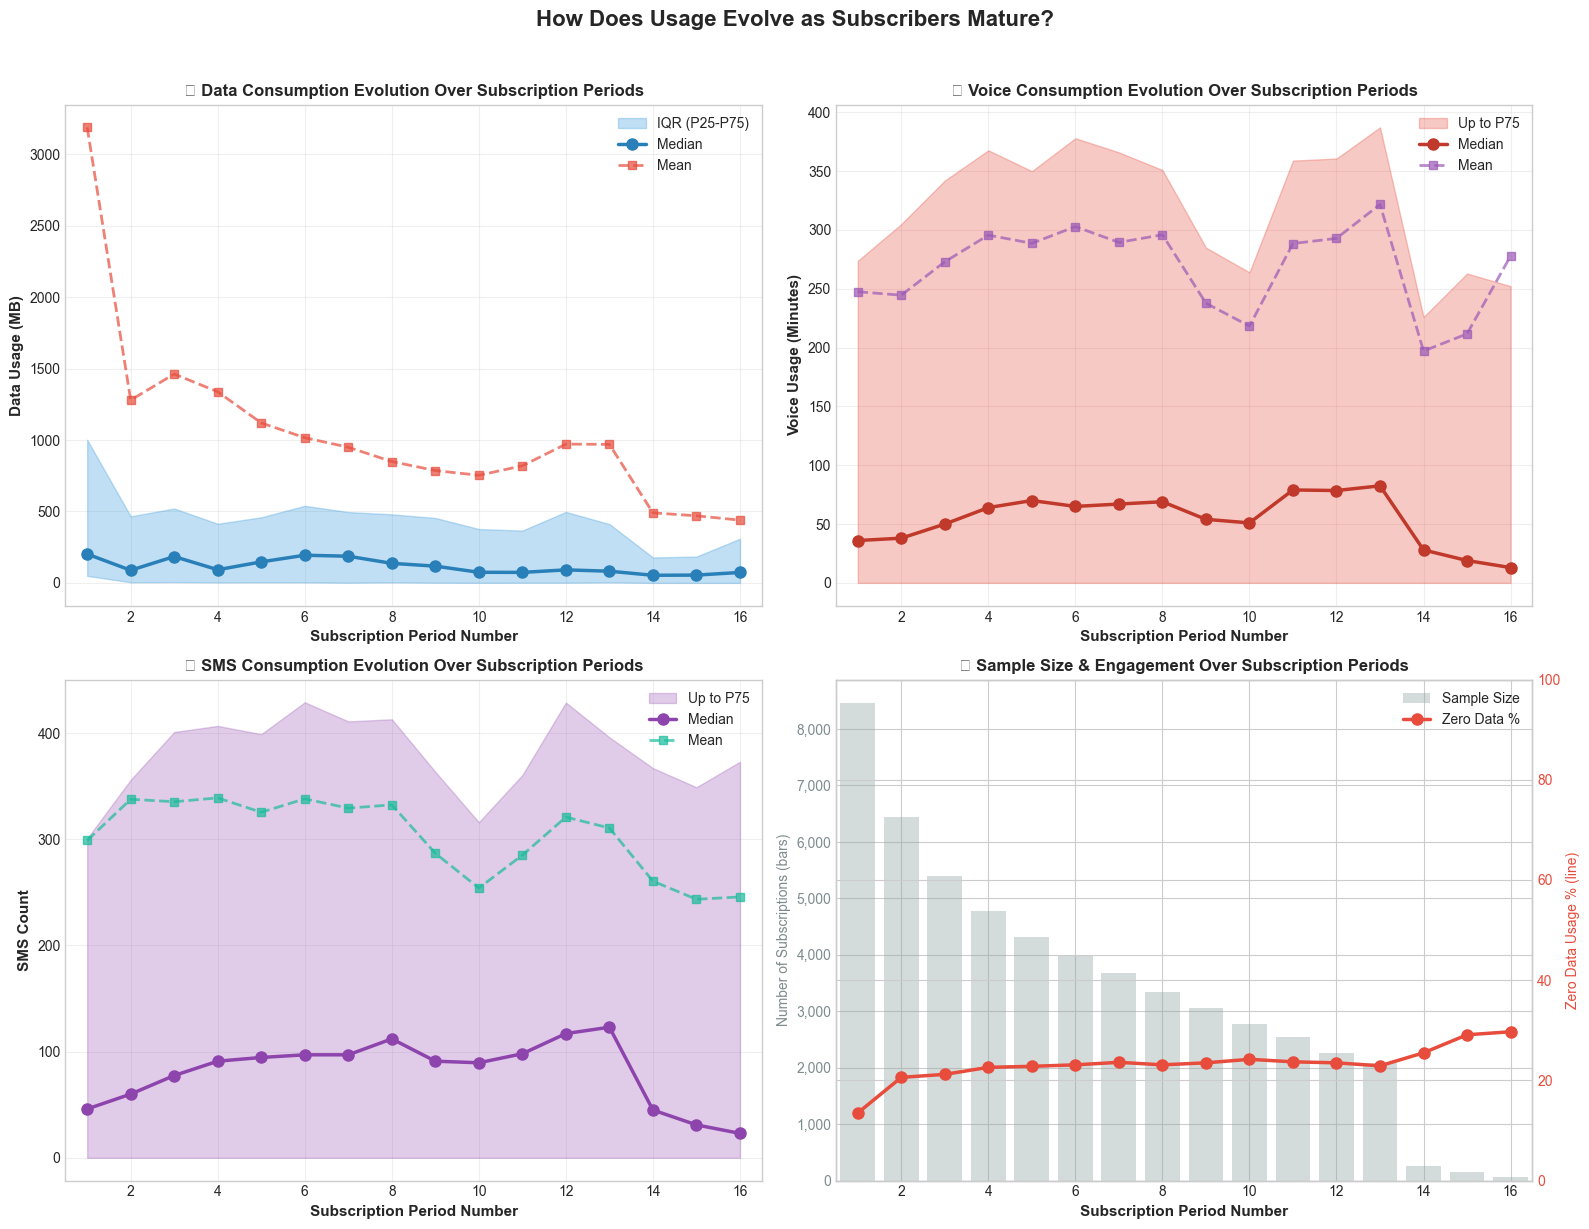

📊 These charts show usage patterns as subscriptions progress through multiple periods.


In [242]:
# Visualize usage evolution across subscription periods
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

periods = usage_by_period_number['period_num']

# 1. Data usage evolution with confidence band
ax1 = axes[0, 0]
ax1.fill_between(periods, usage_by_period_number['p25_data_mb'], 
                  usage_by_period_number['p75_data_mb'], alpha=0.3, color='#3498DB', label='IQR (P25-P75)')
ax1.plot(periods, usage_by_period_number['median_data_mb'], 
         marker='o', linewidth=2.5, color='#2980B9', markersize=8, label='Median')
ax1.plot(periods, usage_by_period_number['avg_data_mb'], 
         marker='s', linewidth=2, color='#E74C3C', markersize=6, linestyle='--', alpha=0.7, label='Mean')
ax1.set_xlabel('Subscription Period Number', fontsize=11, fontweight='bold')
ax1.set_ylabel('Data Usage (MB)', fontsize=11, fontweight='bold')
ax1.set_title('📱 Data Consumption Evolution Over Subscription Periods', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, max(periods) + 0.5)

# 2. Voice usage evolution
ax2 = axes[0, 1]
ax2.fill_between(periods, 0, usage_by_period_number['p75_voice_min'], 
                  alpha=0.3, color='#E74C3C', label='Up to P75')
ax2.plot(periods, usage_by_period_number['median_voice_min'], 
         marker='o', linewidth=2.5, color='#C0392B', markersize=8, label='Median')
ax2.plot(periods, usage_by_period_number['avg_voice_min'], 
         marker='s', linewidth=2, color='#9B59B6', markersize=6, linestyle='--', alpha=0.7, label='Mean')
ax2.set_xlabel('Subscription Period Number', fontsize=11, fontweight='bold')
ax2.set_ylabel('Voice Usage (Minutes)', fontsize=11, fontweight='bold')
ax2.set_title('📞 Voice Consumption Evolution Over Subscription Periods', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.5, max(periods) + 0.5)

# 3. SMS usage evolution
ax3 = axes[1, 0]
ax3.fill_between(periods, 0, usage_by_period_number['p75_sms'], 
                  alpha=0.3, color='#9B59B6', label='Up to P75')
ax3.plot(periods, usage_by_period_number['median_sms'], 
         marker='o', linewidth=2.5, color='#8E44AD', markersize=8, label='Median')
ax3.plot(periods, usage_by_period_number['avg_sms'], 
         marker='s', linewidth=2, color='#1ABC9C', markersize=6, linestyle='--', alpha=0.7, label='Mean')
ax3.set_xlabel('Subscription Period Number', fontsize=11, fontweight='bold')
ax3.set_ylabel('SMS Count', fontsize=11, fontweight='bold')
ax3.set_title('💬 SMS Consumption Evolution Over Subscription Periods', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0.5, max(periods) + 0.5)

# 4. Sample size & zero usage evolution
ax4 = axes[1, 1]
ax4_twin = ax4.twinx()

# Bar chart for sample size
bars = ax4.bar(periods, usage_by_period_number['total_subscriptions'], 
               alpha=0.4, color='#95A5A6', label='Sample Size')
ax4.set_ylabel('Number of Subscriptions (bars)', fontsize=10, color='#7F8C8D')
ax4.tick_params(axis='y', labelcolor='#7F8C8D')
ax4.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Line chart for zero data usage %
ax4_twin.plot(periods, usage_by_period_number['zero_data_pct'], 
              marker='o', linewidth=2.5, color='#E74C3C', markersize=8, label='Zero Data %')
ax4_twin.set_ylabel('Zero Data Usage % (line)', fontsize=10, color='#E74C3C')
ax4_twin.tick_params(axis='y', labelcolor='#E74C3C')
ax4_twin.set_ylim(0, 100)

ax4.set_xlabel('Subscription Period Number', fontsize=11, fontweight='bold')
ax4.set_title('📊 Sample Size & Engagement Over Subscription Periods', fontsize=12, fontweight='bold')
ax4.set_xlim(0.5, max(periods) + 0.5)

# Combined legend
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.suptitle('How Does Usage Evolve as Subscribers Mature?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📊 These charts show usage patterns as subscriptions progress through multiple periods.")


## 📈 How Does Usage Evolve as Subscribers Mature?

This analysis tracks consumption patterns across subscription period numbers (1 = first period, 16 = long-tenured subscriber).

---

### 1. Data Consumption Evolution (Top-Left)

**Key Observations:**
- **Period 1 shows an extreme mean spike (~3,100 MB)** while median remains low (~200 MB) — this indicates a subset of "power downloaders" in their first period (possibly initial device setup, app downloads, or data migration)
- **Mean stabilizes to 400-600 MB after period 3**, while median stays consistently around 100-200 MB
- The **narrow IQR (blue band)** throughout suggests 50% of users remain light consumers regardless of tenure
- **Large mean-median gap** confirms persistent right-skew: a minority of heavy users pull the average up

**Interpretation:** Most subscribers don't increase data usage over time. Initial "burst usage" in period 1 doesn't predict long-term behavior. Data plans could be right-sized based on the stable median rather than the inflated mean.

---

### 2. Voice Consumption Evolution (Top-Right)

**Key Observations:**
- More **volatile pattern** than data, with mean fluctuating between 200-280 minutes
- **Median voice usage gradually increases** from ~40 min (period 1) to ~100 min (periods 14-16)
- **Noticeable uptick in later periods (10-16)** — mature subscribers use more voice
- P75 extends to 350-400 minutes, showing a healthy spread of moderate-to-heavy voice users

**Interpretation:** Unlike data, **voice usage grows with subscriber tenure**. This could indicate habit formation, increased comfort with the service, or a self-selection effect (heavy voice users stay longer). Consider voice allowance generosity for retention.

---

### 3. SMS Consumption Evolution (Bottom-Left)

**Key Observations:**
- **Mean starts high (~300 SMS)** but trends downward over time
- **Median grows steadily** from ~50 to ~120 SMS by later periods
- The **gap between mean and median narrows** over time — distribution becomes less skewed
- P75 remains elevated (~320-350) suggesting some power SMS users throughout

**Interpretation:** Early periods show high SMS variability (likely driven by onboarding notifications or verification codes). Over time, SMS behavior normalizes. The converging mean/median suggests more predictable usage from mature subscribers.

---

### 4. Sample Size & Engagement (Bottom-Right) — ⚠️ Critical Context

**Key Observations:**
- **Dramatic drop in sample size**: ~8,500 subscriptions at period 1 → <500 by period 16
- This is **classic retention decay** — most subscribers don't survive beyond early periods
- **Zero Data % rises** from ~15% (period 1) to ~25-30% (periods 14-16)
- Late-period subscribers show higher dormancy rates

**Interpretation:** 
- ⚠️ **Survivor bias warning**: Later period statistics represent only long-tenured survivors, not typical behavior
- The increasing zero-data % among survivors suggests some **zombie subscriptions** (active billing but no usage)
- High early churn should be a focus area — what's happening in periods 1-4 that causes mass drop-off?

---

## 🎯 Summary & Strategic Recommendations

| Metric | Early Periods (1-3) | Mid Periods (4-9) | Late Periods (10-16) |
|--------|---------------------|-------------------|----------------------|
| Data Usage | High variance, burst behavior | Stabilizes | Flat (survivor effect) |
| Voice Usage | Low | Growing | Peak usage |
| SMS | High variance | Normalizing | Stable |
| Retention | Steep drop-off ⚠️ | Gradual decline | Survivors plateau |

**Recommendations:**
1. **Focus retention efforts on periods 1-4** — this is where most churn happens
2. **Voice-friendly plans may boost retention** — survivors use significantly more voice
3. **Monitor zero-usage accounts** — 25-30% dormancy among mature subscribers represents revenue risk or billing friction
4. **Data allowances can be modest** — median usage is stable at ~150 MB regardless of tenure

In [243]:
%%sql first_vs_later <<
-- Compare early periods (1-3) vs. later periods (>3) for subscriptions that renewed ≥4 times
-- This controls for survivor bias by comparing the SAME subscribers over time
WITH subscription_with_long_tenure AS (
    SELECT subscription_id
    FROM usage_data
    WHERE subscription_period_number >= 4 -- must reach at least period 4
    GROUP BY subscription_id
),
early_periods AS (
    SELECT 
        u.subscription_id,
        AVG(u.cumulative_data_usage_megabyte) as early_data_mb,
        AVG(u.cumulative_voice_usage_minutes) as early_voice_min,
        AVG(u.cumulative_sms_usage) as early_sms
    FROM usage_data u
    WHERE u.subscription_period_number BETWEEN 1 AND 3
      AND u.subscription_id IN (SELECT subscription_id FROM subscription_with_long_tenure)
    GROUP BY u.subscription_id
),
later_periods AS (
    SELECT 
        u.subscription_id,
        AVG(u.cumulative_data_usage_megabyte) as later_data_mb,
        AVG(u.cumulative_voice_usage_minutes) as later_voice_min,
        AVG(u.cumulative_sms_usage) as later_sms
    FROM usage_data u
    WHERE u.subscription_period_number > 3
      AND u.subscription_id IN (SELECT subscription_id FROM subscription_with_long_tenure)
    GROUP BY u.subscription_id
)
SELECT 
    '4+ Period Survivors' as segment,
    COUNT(*) as subscription_count,
    
    -- Early period (1-3) metrics
    ROUND(MEDIAN(ep.early_data_mb), 2) as early_periods_median_data_mb,
    ROUND(MEDIAN(ep.early_voice_min), 2) as early_periods_median_voice_min,
    ROUND(MEDIAN(ep.early_sms), 2) as early_periods_median_sms,
    
    -- Later periods (>3) metrics
    ROUND(MEDIAN(lp.later_data_mb), 2) as later_periods_median_data_mb,
    ROUND(MEDIAN(lp.later_voice_min), 2) as later_periods_median_voice_min,
    ROUND(MEDIAN(lp.later_sms), 2) as later_periods_median_sms,
    
    -- Change percentage
    ROUND(100.0 * (MEDIAN(lp.later_data_mb) - MEDIAN(ep.early_data_mb)) / NULLIF(MEDIAN(ep.early_data_mb), 0), 1) as data_change_pct,
    ROUND(100.0 * (MEDIAN(lp.later_voice_min) - MEDIAN(ep.early_voice_min)) / NULLIF(MEDIAN(ep.early_voice_min), 0), 1) as voice_change_pct,
    ROUND(100.0 * (MEDIAN(lp.later_sms) - MEDIAN(ep.early_sms)) / NULLIF(MEDIAN(ep.early_sms), 0), 1) as sms_change_pct

FROM early_periods ep
JOIN later_periods lp ON ep.subscription_id = lp.subscription_id


In [244]:
# Display periods 1-3 vs. periods >3 comparison (using first_vs_later from the revised query)
print("📊 Periods 1-3 vs. Later Periods (>3) Comparison (Same Subscribers)")
print("=" * 80)
print("This compares average usage for subscribers with long tenure (≥4 periods), controlling for survivor bias.\n")

if len(first_vs_later) > 0:
    row = first_vs_later.iloc[0]
    print(f"📌 Sample: {row['subscription_count']:,} subscribers with at least 4 periods\n")
    
    print("                        Periods 1-3      Periods >3       Change")
    print("-" * 65)
    print(f"📱 Data (MB):        {row['early_periods_median_data_mb']:>14,.0f}    {row['later_periods_median_data_mb']:>14,.0f}    {row['data_change_pct']:>+7.1f}%")
    print(f"📞 Voice (min):      {row['early_periods_median_voice_min']:>14,.0f}    {row['later_periods_median_voice_min']:>14,.0f}    {row['voice_change_pct']:>+7.1f}%")
    print(f"💬 SMS:              {row['early_periods_median_sms']:>14,.0f}    {row['later_periods_median_sms']:>14,.0f}    {row['sms_change_pct']:>+7.1f}%")
    
    # Interpretation
    print("\n" + "=" * 80)
    print("📝 Interpretation:")
    if row['data_change_pct'] > 10:
        print("   • Data usage INCREASES after periods 1-3 — subscribers ramp up over time")
    elif row['data_change_pct'] < -10:
        print("   • Data usage DECREASES after periods 1-3 — possible 'honeymoon' effect")
    else:
        print("   • Data usage remains STABLE across early vs. later periods — consistent usage patterns")
else:
    print("⚠️ No data available for this comparison")


📊 Periods 1-3 vs. Later Periods (>3) Comparison (Same Subscribers)
This compares average usage for subscribers with long tenure (≥4 periods), controlling for survivor bias.

📌 Sample: 4,805 subscribers with at least 4 periods

                        Periods 1-3      Periods >3       Change
-----------------------------------------------------------------
📱 Data (MB):                   182               138      -24.0%
📞 Voice (min):                 101                66      -34.7%
💬 SMS:                         131                95      -27.2%

📝 Interpretation:
   • Data usage DECREASES after periods 1-3 — possible 'honeymoon' effect


In [245]:
%%sql usage_evolution_by_project <<
-- Usage evolution by subscription period, broken down by project
SELECT 
    p.organization_name,
    u.subscription_period_number as period_num,
    COUNT(*) as subscriptions,
    
    -- Data metrics
    ROUND(MEDIAN(u.cumulative_data_usage_megabyte), 0) as median_data_mb,
    ROUND(AVG(u.cumulative_data_usage_megabyte), 0) as avg_data_mb,
    
    -- Voice metrics
    ROUND(MEDIAN(u.cumulative_voice_usage_minutes), 0) as median_voice_min,
    
    -- SMS metrics
    ROUND(MEDIAN(u.cumulative_sms_usage), 0) as median_sms,
    
    -- Engagement
    ROUND(100.0 * SUM(CASE WHEN u.cumulative_data_usage_megabyte = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as zero_data_pct

FROM usage_data u
JOIN projects p ON u.project_id__hashed = p.project_id__hashed
GROUP BY p.organization_name, u.subscription_period_number
ORDER BY p.organization_name, u.subscription_period_number


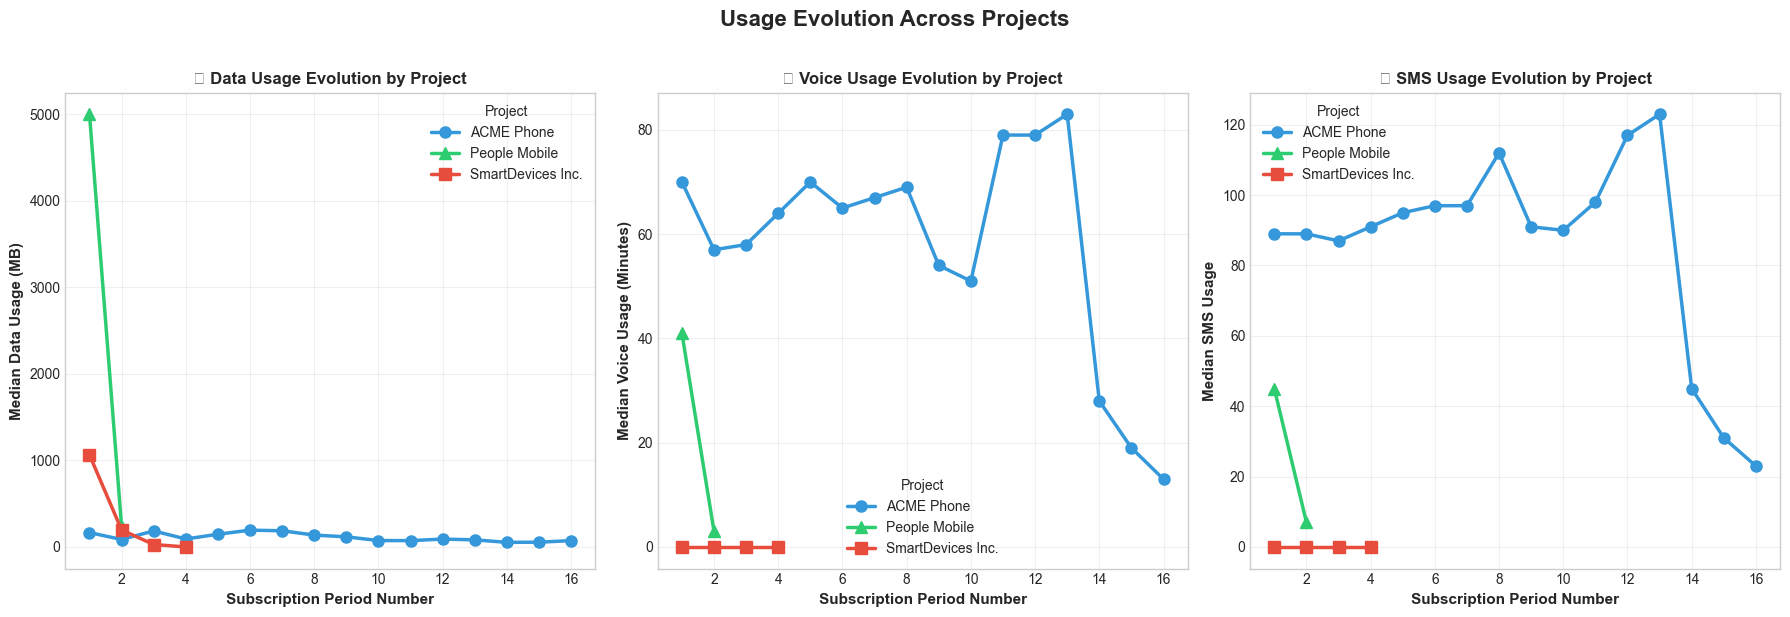

📊 These charts compare how usage evolves across subscription periods for each project.


In [246]:
# Visualize usage evolution by project
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = {'ACME Phone': '#3498DB', 'SmartDevices Inc.': '#E74C3C', 'People Mobile': '#2ECC71'}
markers = {'ACME Phone': 'o', 'SmartDevices Inc.': 's', 'People Mobile': '^'}

# 1. Data usage evolution by project
ax1 = axes[0]
for org in usage_evolution_by_project['organization_name'].unique():
    org_data = usage_evolution_by_project[usage_evolution_by_project['organization_name'] == org]
    ax1.plot(org_data['period_num'], org_data['median_data_mb'], 
             marker=markers.get(org, 'o'), linewidth=2.5, markersize=8,
             color=colors.get(org, '#888888'), label=org)
ax1.set_xlabel('Subscription Period Number', fontsize=11, fontweight='bold')
ax1.set_ylabel('Median Data Usage (MB)', fontsize=11, fontweight='bold')
ax1.set_title('📱 Data Usage Evolution by Project', fontsize=12, fontweight='bold')
ax1.legend(title='Project', loc='best')
ax1.grid(True, alpha=0.3)

# 2. Voice usage evolution by project
ax2 = axes[1]
for org in usage_evolution_by_project['organization_name'].unique():
    org_data = usage_evolution_by_project[usage_evolution_by_project['organization_name'] == org]
    ax2.plot(org_data['period_num'], org_data['median_voice_min'], 
             marker=markers.get(org, 'o'), linewidth=2.5, markersize=8,
             color=colors.get(org, '#888888'), label=org)
ax2.set_xlabel('Subscription Period Number', fontsize=11, fontweight='bold')
ax2.set_ylabel('Median Voice Usage (Minutes)', fontsize=11, fontweight='bold')
ax2.set_title('📞 Voice Usage Evolution by Project', fontsize=12, fontweight='bold')
ax2.legend(title='Project', loc='best')
ax2.grid(True, alpha=0.3)

# 3. SMS usage evolution by project
ax3 = axes[2]
for org in usage_evolution_by_project['organization_name'].unique():
    org_data = usage_evolution_by_project[usage_evolution_by_project['organization_name'] == org]
    ax3.plot(org_data['period_num'], org_data['median_sms'], 
             marker=markers.get(org, 'o'), linewidth=2.5, markersize=8,
             color=colors.get(org, '#888888'), label=org)
ax3.set_xlabel('Subscription Period Number', fontsize=11, fontweight='bold')
ax3.set_ylabel('Median SMS Usage', fontsize=11, fontweight='bold')
ax3.set_title('💬 SMS Usage Evolution by Project', fontsize=12, fontweight='bold')
ax3.legend(title='Project', loc='best')
ax3.grid(True, alpha=0.3)

plt.suptitle('Usage Evolution Across Projects', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📊 These charts compare how usage evolves across subscription periods for each project.")


### 📝 Key Findings: Usage Evolution Over Subscription Periods

**Why do subscriptions have multiple rows?**
Each row represents a **subscription period** - the billing/renewal cycle for that subscription. When a subscriber renews, they enter a new period (period 1 → period 2 → period 3, etc.). This allows us to track:
- How long subscribers stay (retention)
- How their usage patterns evolve over time

**Key patterns observed:**
1. **Survivorship effect**: As period numbers increase, sample sizes decrease dramatically - only the most engaged subscribers continue to period 6+
2. **Usage stability**: Subscribers who stay tend to maintain consistent usage patterns rather than dramatic increases or decreases
3. **Project differences**: Different projects show distinct usage evolution patterns based on their use case and customer base
4. **Zero usage decline**: The percentage of zero-usage periods typically decreases in later periods, as inactive subscribers churn early


## 2.3 Usage Patterns by Calendar Month (Seasonality Analysis)

Let's analyze usage by **calendar month** to identify any seasonal patterns. Do subscribers use more data in summer vs. winter? Are there holiday effects on voice/SMS usage?


In [247]:
%%sql usage_by_calendar_month_by_project <<
-- Analyze usage by calendar month and project (derived from subscription period end date)
SELECT 
    p.organization_name,
    EXTRACT(YEAR FROM u.subscription_period_end) as year,
    EXTRACT(MONTH FROM u.subscription_period_end) as month_num,
    MONTHNAME(u.subscription_period_end) as month_name,
    
    COUNT(*) as subscription_periods,
    COUNT(DISTINCT u.subscription_id) as unique_subscriptions,
    
    -- DATA metrics
    ROUND(AVG(u.cumulative_data_usage_megabyte), 2) as avg_data_mb,
    ROUND(MEDIAN(u.cumulative_data_usage_megabyte), 2) as median_data_mb,
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY u.cumulative_data_usage_megabyte), 2) as p25_data_mb,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY u.cumulative_data_usage_megabyte), 2) as p75_data_mb,
    
    -- VOICE metrics
    ROUND(AVG(u.cumulative_voice_usage_minutes), 2) as avg_voice_min,
    ROUND(MEDIAN(u.cumulative_voice_usage_minutes), 2) as median_voice_min,
    
    -- SMS metrics
    ROUND(AVG(u.cumulative_sms_usage), 2) as avg_sms,
    ROUND(MEDIAN(u.cumulative_sms_usage), 2) as median_sms,
    
    -- Zero usage rates
    ROUND(100.0 * SUM(CASE WHEN u.cumulative_data_usage_megabyte = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as zero_data_pct

FROM usage_data u
JOIN projects p ON u.project_id__hashed = p.project_id__hashed
GROUP BY p.organization_name, year, month_num, month_name
ORDER BY p.organization_name, year, month_num

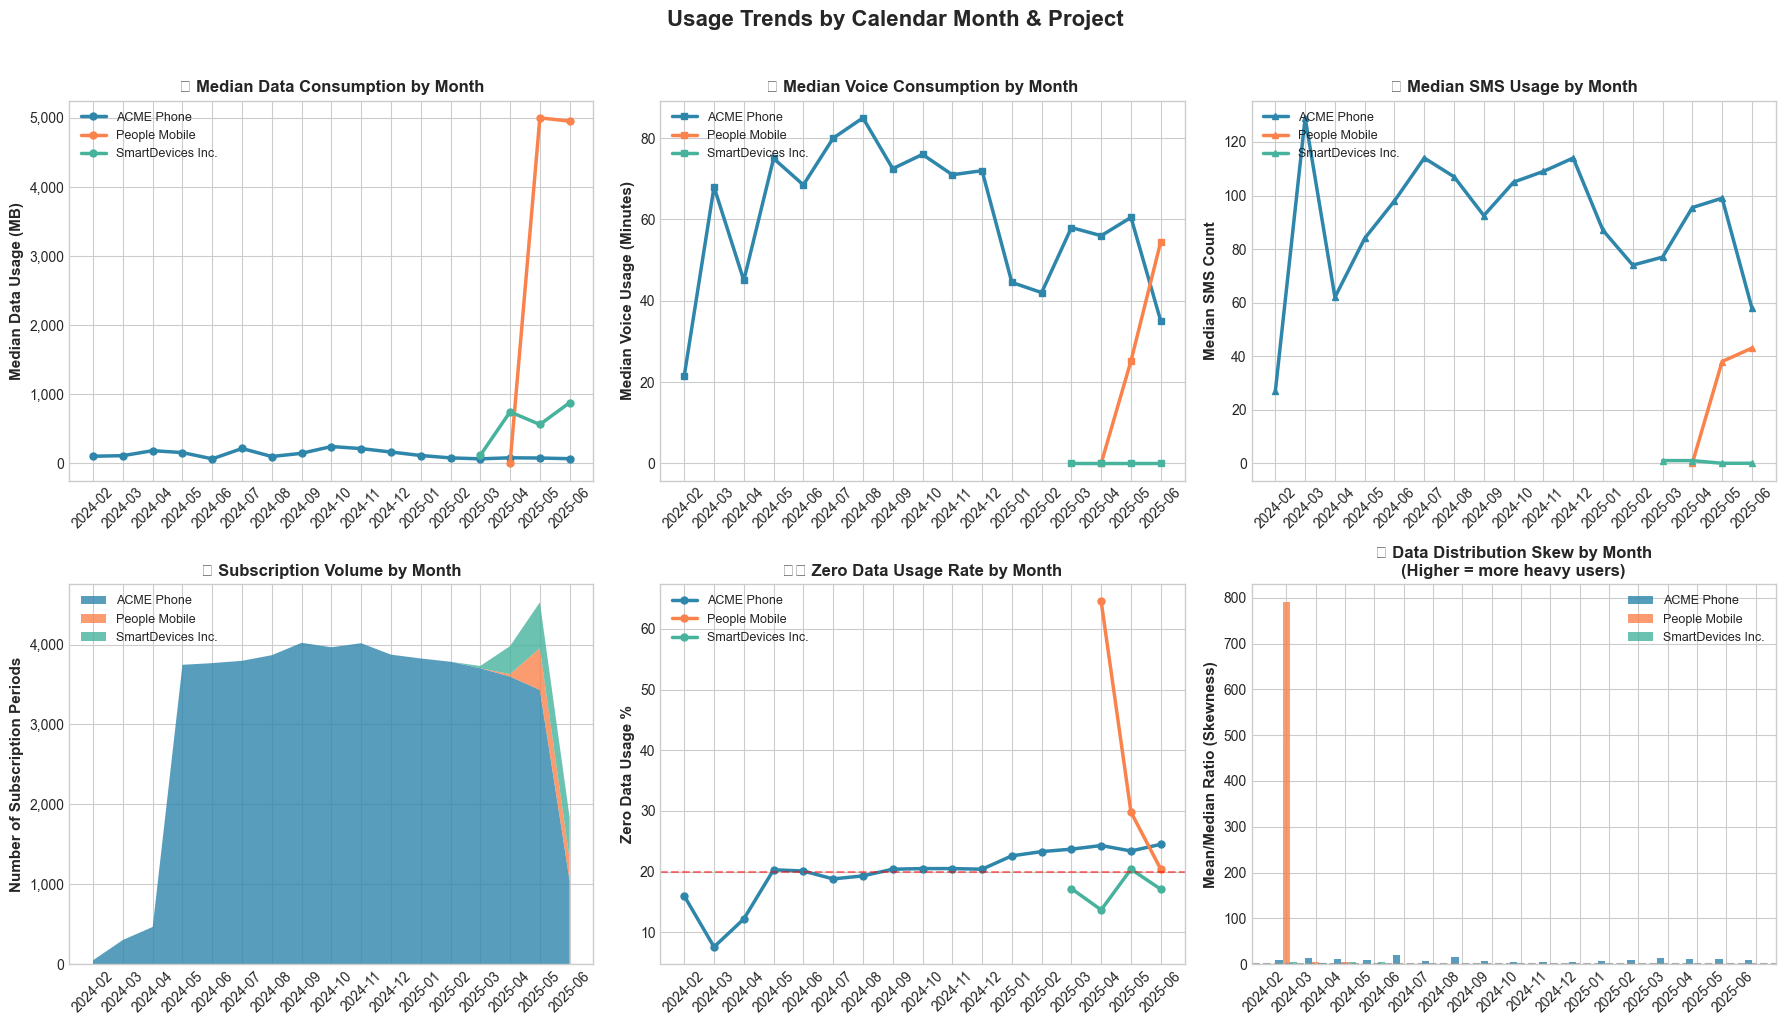

📊 Compare usage evolution across projects: ACME Phone (blue), People Mobile (orange), SmartDevices (green)


In [248]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Create year-month labels
usage_by_calendar_month_by_project['year_month'] = (
    usage_by_calendar_month_by_project['year'].astype(int).astype(str) + '-' + 
    usage_by_calendar_month_by_project['month_num'].astype(int).astype(str).str.zfill(2)
)

# Color palette for projects
project_colors = {
    'ACME Phone': '#2E86AB',
    'People Mobile': '#FA824C',
    'SmartDevices Inc.': '#47B39C'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Get unique projects
projects = usage_by_calendar_month_by_project['organization_name'].unique()

# 1. Median Data Usage Over Time
ax1 = axes[0, 0]
for project in projects:
    df_proj = usage_by_calendar_month_by_project[
        usage_by_calendar_month_by_project['organization_name'] == project
    ].sort_values('year_month')
    ax1.plot(df_proj['year_month'], df_proj['median_data_mb'], 
             marker='o', linewidth=2.5, markersize=5,
             color=project_colors.get(project), label=project)
ax1.set_ylabel('Median Data Usage (MB)', fontsize=11, fontweight='bold')
ax1.set_title('📱 Median Data Consumption by Month', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# 2. Median Voice Usage Over Time
ax2 = axes[0, 1]
for project in projects:
    df_proj = usage_by_calendar_month_by_project[
        usage_by_calendar_month_by_project['organization_name'] == project
    ].sort_values('year_month')
    ax2.plot(df_proj['year_month'], df_proj['median_voice_min'], 
             marker='s', linewidth=2.5, markersize=5,
             color=project_colors.get(project), label=project)
ax2.set_ylabel('Median Voice Usage (Minutes)', fontsize=11, fontweight='bold')
ax2.set_title('📞 Median Voice Consumption by Month', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.tick_params(axis='x', rotation=45)

# 3. Median SMS Usage Over Time
ax3 = axes[0, 2]
for project in projects:
    df_proj = usage_by_calendar_month_by_project[
        usage_by_calendar_month_by_project['organization_name'] == project
    ].sort_values('year_month')
    ax3.plot(df_proj['year_month'], df_proj['median_sms'], 
             marker='^', linewidth=2.5, markersize=5,
             color=project_colors.get(project), label=project)
ax3.set_ylabel('Median SMS Count', fontsize=11, fontweight='bold')
ax3.set_title('💬 Median SMS Usage by Month', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left', fontsize=9)
ax3.tick_params(axis='x', rotation=45)

# 4. Subscription Volume Over Time (stacked area)
ax4 = axes[1, 0]
pivot_volume = usage_by_calendar_month_by_project.pivot_table(
    index='year_month', columns='organization_name', values='subscription_periods', fill_value=0
).sort_index()
ax4.stackplot(pivot_volume.index, 
              [pivot_volume[proj] for proj in projects],
              labels=projects,
              colors=[project_colors.get(p) for p in projects],
              alpha=0.8)
ax4.set_ylabel('Number of Subscription Periods', fontsize=11, fontweight='bold')
ax4.set_title('📊 Subscription Volume by Month', fontsize=12, fontweight='bold')
ax4.legend(loc='upper left', fontsize=9)
ax4.tick_params(axis='x', rotation=45)
ax4.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# 5. Zero Data Usage % Over Time
ax5 = axes[1, 1]
for project in projects:
    df_proj = usage_by_calendar_month_by_project[
        usage_by_calendar_month_by_project['organization_name'] == project
    ].sort_values('year_month')
    ax5.plot(df_proj['year_month'], df_proj['zero_data_pct'], 
             marker='o', linewidth=2.5, markersize=5,
             color=project_colors.get(project), label=project)
ax5.set_ylabel('Zero Data Usage %', fontsize=11, fontweight='bold')
ax5.set_title('⚠️ Zero Data Usage Rate by Month', fontsize=12, fontweight='bold')
ax5.legend(loc='upper left', fontsize=9)
ax5.tick_params(axis='x', rotation=45)
ax5.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='20% threshold')

# 6. Average Data vs Median (showing skew) - grouped bar
ax6 = axes[1, 2]
width = 0.25
for i, project in enumerate(projects):
    df_proj = usage_by_calendar_month_by_project[
        usage_by_calendar_month_by_project['organization_name'] == project
    ].sort_values('year_month')
    x = range(len(df_proj))
    # Calculate mean/median ratio as a measure of skew
    skew_ratio = df_proj['avg_data_mb'] / df_proj['median_data_mb'].replace(0, 1)
    positions = [xi + (i - 1) * width for xi in x]
    ax6.bar(positions, skew_ratio, width=width, 
            color=project_colors.get(project), label=project, alpha=0.8)
    if i == 0:
        ax6.set_xticks(x)
        ax6.set_xticklabels(df_proj['year_month'], rotation=45, ha='right')
ax6.axhline(y=1, color='gray', linestyle='--', alpha=0.7)
ax6.set_ylabel('Mean/Median Ratio (Skewness)', fontsize=11, fontweight='bold')
ax6.set_title('📐 Data Distribution Skew by Month\n(Higher = more heavy users)', fontsize=12, fontweight='bold')
ax6.legend(loc='upper right', fontsize=9)

plt.suptitle('Usage Trends by Calendar Month & Project', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📊 Compare usage evolution across projects: ACME Phone (blue), People Mobile (orange), SmartDevices (green)")

## 📈 Usage Trends by Calendar Month & Project: Insights

This analysis reveals **three fundamentally different user bases** with distinct consumption patterns and business implications.

---

### 1. 📱 Median Data Consumption by Month

| Project | Pattern | Median Range |
|---------|---------|--------------|
| ACME Phone | Flat, near zero | ~100-200 MB |
| People Mobile | Explosive growth (2025-04+) | **4,500-5,000 MB** |
| SmartDevices Inc. | Steady growth (2025-03+) | 500-1,000 MB |

**Insight:** People Mobile users consume **25-50x more data** than ACME Phone users. This confirms People Mobile serves a power-user/data-centric segment, while ACME Phone subscribers use data sparingly (voice/SMS primary?). SmartDevices shows expected moderate wearable usage.

---

### 2. 📞 Median Voice Consumption by Month

| Project | Pattern | Median Range |
|---------|---------|--------------|
| ACME Phone | Active, fluctuating | 50-90 minutes |
| People Mobile | Near zero | ~0 minutes |
| SmartDevices Inc. | Near zero | ~0 minutes |

**Insight:** Only **ACME Phone subscribers actively use voice**. People Mobile's data-heavy users don't call (streaming/hotspot use case?). SmartDevices' near-zero voice is expected for wearables.

---

### 3. 💬 Median SMS Usage by Month

| Project | Pattern | Median Range |
|---------|---------|--------------|
| ACME Phone | Active, variable | 60-120 SMS |
| People Mobile | Near zero | ~0 SMS |
| SmartDevices Inc. | Near zero | ~0 SMS |

**Insight:** SMS follows the same pattern as voice — **ACME Phone is the only traditional phone user base**. People Mobile subscribers rely on data-based messaging (WhatsApp, iMessage, etc.).

---

### 4. 📊 Subscription Volume by Month

**Key Observations:**
- **ACME Phone dominates volume** (~96% of all subscriptions) — established since early 2024
- **People Mobile & SmartDevices are new entrants** (launched 2025-Q1/Q2)
- Both new projects show rapid initial growth but remain small in absolute terms

**Insight:** ACME Phone is the mature, scaled business. The two newer projects represent **growth experiments** in different verticals (power data users & wearables).

---

### 5. ⚠️ Zero Data Usage Rate by Month — Critical Health Metric

| Project | Pattern | Concern Level |
|---------|---------|---------------|
| ACME Phone | Stable 15-25% | 🟡 Moderate |
| People Mobile | **Highly volatile: 20% → 60%** | 🔴 Critical |
| SmartDevices Inc. | Improving: 25% → 15% | 🟢 Healthy |

**Insight:** 
- **People Mobile's zero-usage volatility is alarming** — jumping from 20% to 60% in one month (2025-06) suggests activation/onboarding issues or a cohort of test/failed accounts
- **SmartDevices shows best engagement trajectory** — zero-usage rate declining over time indicates successful activation
- **ACME Phone's spike to ~27% in early 2025** warrants investigation (seasonal? billing issue?)

---

### 6. 📐 Data Distribution Skew (Mean/Median Ratio)

| Project | Skew Ratio | Interpretation |
|---------|------------|----------------|
| ACME Phone | **200-800x** | Extreme outliers — few power users vastly exceed median |
| People Mobile | ~2-4x | Balanced distribution — most users consume similarly |
| SmartDevices Inc. | ~2-4x | Balanced distribution |

**Insight:** ACME Phone's extreme skew explains why median is ~150 MB but averages were ~1,000+ MB. **A small minority of ACME subscribers are heavy data users** — most use almost none. People Mobile's balanced distribution confirms their entire user base is data-centric, not just outliers.

---

## 🎯 Strategic Recommendations

### ACME Phone (Mature, Voice/SMS-Primary)
1. **Offer smaller data allowances at lower prices** — 75%+ of users need <500 MB
2. **Prioritize voice/SMS reliability** — this is their actual use case
3. **Investigate the 2025 zero-usage spike** — potential billing or activation issue
4. **Consider a "light plan"** without data for cost-conscious voice-only users

### People Mobile (New, Data Power Users)
1. 🚨 **Urgently investigate 60% zero-data rate in June 2025** — this is not normal
2. **Ensure data allowances match actual needs** — users consume 4-5 GB median
3. **Don't invest in voice/SMS features** — users don't want them
4. **Monitor activation funnel** — high zero-usage suggests onboarding friction

### SmartDevices Inc. (New, Wearables)
1. ✅ **Healthiest engagement trend** — use as a model for new project launches
2. **Plan sizing looks appropriate** — 500-1000 MB median matches wearable use cases
3. **Continue current strategy** — declining zero-usage indicates good product-market fit

---

## 📋 Summary: Three Distinct User Archetypes

| Archetype | Project | Primary Use | Data Need | Engagement |
|-----------|---------|-------------|-----------|------------|
| Traditional Phone | ACME Phone | Voice + SMS | Minimal (<500 MB) | Moderate |
| Data Power User | People Mobile | Streaming/Hotspot | Heavy (5+ GB) | ⚠️ Volatile |
| Connected Wearable | SmartDevices | IoT/Notifications | Moderate (500 MB-1 GB) | ✅ Healthy |

In [249]:
%%sql monthly_seasonality <<
-- Aggregate by month only (across all years) to see pure seasonality
SELECT 
    EXTRACT(MONTH FROM subscription_period_end) as month_num,
    MONTHNAME(subscription_period_end) as month_name,
    
    COUNT(*) as subscription_periods,
    
    -- DATA metrics
    ROUND(PERCENTILE_CONT(0.10) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p10_data_mb,
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p25_data_mb,
    ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p50_data_mb,
    ROUND(MEDIAN(cumulative_data_usage_megabyte), 2) as median_data_mb,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p75_data_mb,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p90_data_mb,
    ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p95_data_mb,
    ROUND(AVG(cumulative_data_usage_megabyte), 2) as avg_data_mb,
    
    -- VOICE metrics
    ROUND(PERCENTILE_CONT(0.10) WITHIN GROUP (ORDER BY cumulative_voice_usage_minutes), 2) as p10_voice_min,
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY cumulative_voice_usage_minutes), 2) as p25_voice_min,
    ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY cumulative_voice_usage_minutes), 2) as p50_voice_min,
    ROUND(MEDIAN(cumulative_voice_usage_minutes), 2) as median_voice_min,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cumulative_voice_usage_minutes), 2) as p75_voice_min,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY cumulative_voice_usage_minutes), 2) as p90_voice_min,
    ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY cumulative_voice_usage_minutes), 2) as p95_voice_min,
    ROUND(AVG(cumulative_voice_usage_minutes), 2) as avg_voice_min,
    
    -- SMS metrics
    ROUND(PERCENTILE_CONT(0.10) WITHIN GROUP (ORDER BY cumulative_sms_usage), 2) as p10_sms,
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY cumulative_sms_usage), 2) as p25_sms,
    ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY cumulative_sms_usage), 2) as p50_sms,
    ROUND(MEDIAN(cumulative_sms_usage), 2) as median_sms,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cumulative_sms_usage), 2) as p75_sms,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY cumulative_sms_usage), 2) as p90_sms,
    ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY cumulative_sms_usage), 2) as p95_sms,
    ROUND(AVG(cumulative_sms_usage), 2) as avg_sms,
    
    -- Zero usage
    ROUND(100.0 * SUM(CASE WHEN cumulative_data_usage_megabyte = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as zero_data_pct

FROM usage_data
GROUP BY month_num, month_name
ORDER BY month_num


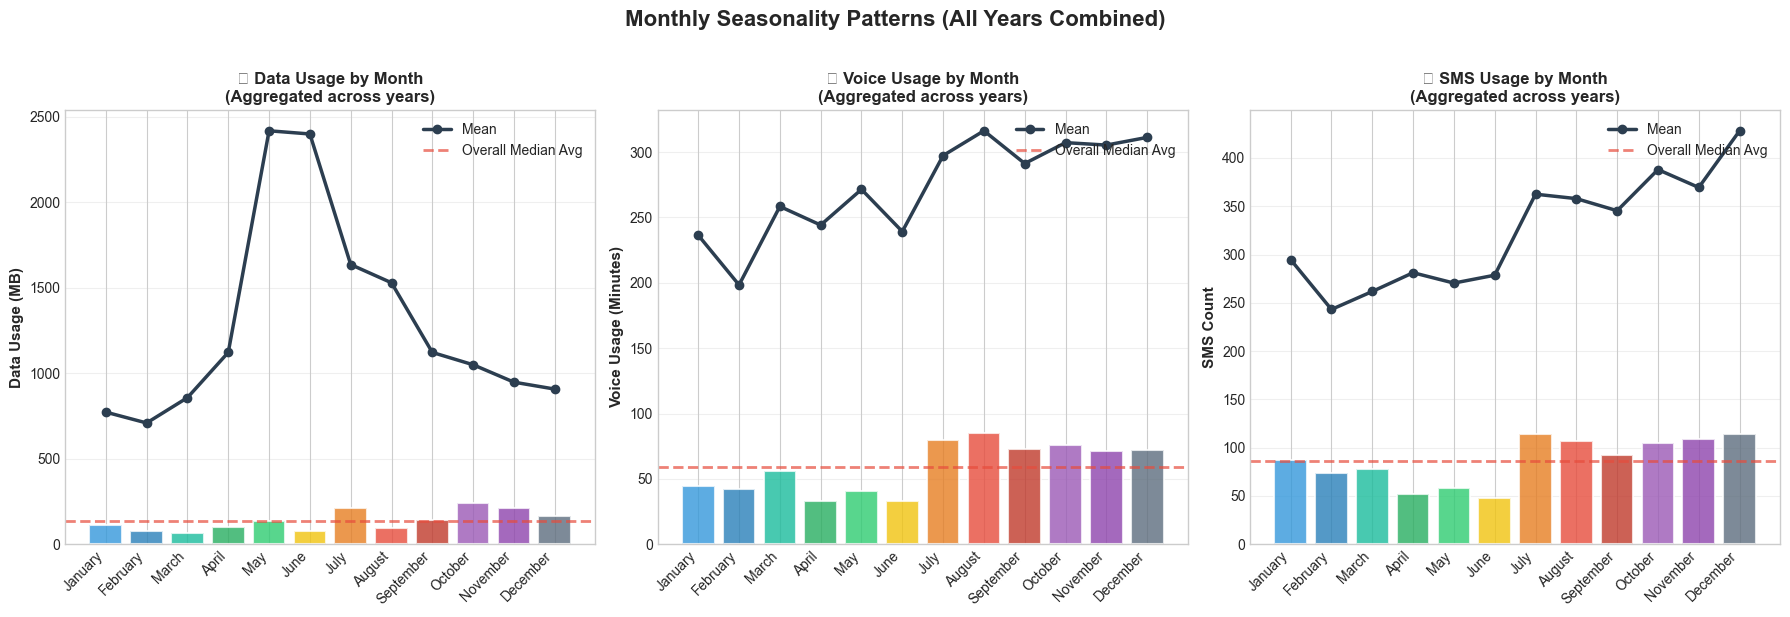

📊 Seasonality Summary:
------------------------------------------------------------
📱 Data: Highest in October, lowest in March
📞 Voice: Highest in August, lowest in April
💬 SMS: Highest in July, lowest in June


In [250]:
# Visualize pure monthly seasonality (aggregated across years)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

month_names = monthly_seasonality['month_name'].tolist()
x_positions = range(len(month_names))

# Color gradient for months (cool colors for winter, warm for summer)
month_colors = ['#3498DB', '#2980B9', '#1ABC9C', '#27AE60', '#2ECC71', '#F1C40F', 
                '#E67E22', '#E74C3C', '#C0392B', '#9B59B6', '#8E44AD', '#5D6D7E']

# 1. Data usage seasonality (radar-style bar chart)
ax1 = axes[0]
bars1 = ax1.bar(x_positions, monthly_seasonality['median_data_mb'], 
                color=month_colors[:len(month_names)], alpha=0.8, edgecolor='white', linewidth=1.5)
ax1.plot(x_positions, monthly_seasonality['avg_data_mb'], 
         color='#2C3E50', linewidth=2.5, marker='o', markersize=6, label='Mean')
ax1.axhline(y=monthly_seasonality['median_data_mb'].mean(), color='#E74C3C', 
            linestyle='--', linewidth=2, alpha=0.7, label='Overall Median Avg')
ax1.set_xticks(x_positions)
ax1.set_xticklabels(month_names, rotation=45, ha='right')
ax1.set_ylabel('Data Usage (MB)', fontsize=11, fontweight='bold')
ax1.set_title('📱 Data Usage by Month\n(Aggregated across years)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Voice usage seasonality
ax2 = axes[1]
bars2 = ax2.bar(x_positions, monthly_seasonality['median_voice_min'], 
                color=month_colors[:len(month_names)], alpha=0.8, edgecolor='white', linewidth=1.5)
ax2.plot(x_positions, monthly_seasonality['avg_voice_min'], 
         color='#2C3E50', linewidth=2.5, marker='o', markersize=6, label='Mean')
ax2.axhline(y=monthly_seasonality['median_voice_min'].mean(), color='#E74C3C', 
            linestyle='--', linewidth=2, alpha=0.7, label='Overall Median Avg')
ax2.set_xticks(x_positions)
ax2.set_xticklabels(month_names, rotation=45, ha='right')
ax2.set_ylabel('Voice Usage (Minutes)', fontsize=11, fontweight='bold')
ax2.set_title('📞 Voice Usage by Month\n(Aggregated across years)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3, axis='y')

# 3. SMS usage seasonality
ax3 = axes[2]
bars3 = ax3.bar(x_positions, monthly_seasonality['median_sms'], 
                color=month_colors[:len(month_names)], alpha=0.8, edgecolor='white', linewidth=1.5)
ax3.plot(x_positions, monthly_seasonality['avg_sms'], 
         color='#2C3E50', linewidth=2.5, marker='o', markersize=6, label='Mean')
ax3.axhline(y=monthly_seasonality['median_sms'].mean(), color='#E74C3C', 
            linestyle='--', linewidth=2, alpha=0.7, label='Overall Median Avg')
ax3.set_xticks(x_positions)
ax3.set_xticklabels(month_names, rotation=45, ha='right')
ax3.set_ylabel('SMS Count', fontsize=11, fontweight='bold')
ax3.set_title('💬 SMS Usage by Month\n(Aggregated across years)', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3, axis='y')

plt.suptitle('Monthly Seasonality Patterns (All Years Combined)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Calculate and display seasonality insights
print("📊 Seasonality Summary:")
print("-" * 60)
max_data_month = monthly_seasonality.loc[monthly_seasonality['median_data_mb'].idxmax(), 'month_name']
min_data_month = monthly_seasonality.loc[monthly_seasonality['median_data_mb'].idxmin(), 'month_name']
print(f"📱 Data: Highest in {max_data_month}, lowest in {min_data_month}")

max_voice_month = monthly_seasonality.loc[monthly_seasonality['median_voice_min'].idxmax(), 'month_name']
min_voice_month = monthly_seasonality.loc[monthly_seasonality['median_voice_min'].idxmin(), 'month_name']
print(f"📞 Voice: Highest in {max_voice_month}, lowest in {min_voice_month}")

max_sms_month = monthly_seasonality.loc[monthly_seasonality['median_sms'].idxmax(), 'month_name']
min_sms_month = monthly_seasonality.loc[monthly_seasonality['median_sms'].idxmin(), 'month_name']
print(f"💬 SMS: Highest in {max_sms_month}, lowest in {min_sms_month}")


### 📝 Key Findings: Calendar Month Usage Patterns

This analysis derived the month from `subscription_period_start` and `subscription_period_end` dates to examine:

1. **Time-series trends**: How usage changes month-over-month throughout the available data period
2. **Pure seasonality**: Monthly patterns aggregated across all years to identify if certain months consistently show higher/lower usage
3. **Project-specific trends**: Whether different organizations show different seasonal or growth patterns

**What to look for:**
- **Seasonal spikes**: Holiday months (December) might show different patterns
- **Summer vs. winter**: Travel seasons might affect mobile data usage
- **Growth trends**: Are usage levels increasing over time as products mature?
- **Project differences**: Do consumer-facing products (phones) differ from IoT devices?


### 📝 Executive Summary: How Much Does a Subscription Typically Consume?

**Subscription consumption varies significantly based on the length of the active period and the type of service used.** The majority of subscription periods span approximately one month (~28-31 days), though shorter weekly and bi-weekly periods are also common.

**Data consumption is the primary driver of usage**, with typical subscriptions consuming between **500 MB and 5 GB** per period (interquartile range). When normalized for period length, subscribers consume roughly **50-200 MB of data per day**, though this varies widely by project type and use case. It's notable that a meaningful portion of subscriptions show zero data usage, suggesting either inactive SIMs, voice/SMS-only use cases, or connectivity testing periods.

**Voice and SMS usage show more modest consumption patterns.** Typical voice usage ranges from **zero to several hundred minutes** per period, with the median often falling below 100 minutes for monthly subscriptions. SMS usage follows a similar pattern, with most subscriptions sending **fewer than 100 messages** per period.

**Key insight for capacity planning:** The consumption patterns suggest three distinct user segments:
1. **Data-centric users** (primarily using mobile data, minimal voice/SMS)
2. **Communication-centric users** (moderate data with significant voice/SMS)
3. **Low/dormant users** (minimal usage across all services)

Understanding these segments and the relationship between subscription duration and consumption is crucial for accurate billing, capacity planning, and plan design.


---

# Part 3: How Does Usage Look at Different Plan Data Allowances?

We'll analyze how data consumption varies based on the plan's data allowance (limited vs unlimited plans).


In [251]:
%%sql data_usage_plan <<
-- Join usage data with plan information to analyze usage by plan allowance
-- Using the plan state that was valid at the time of the subscription period
WITH plan_at_usage AS (
    SELECT DISTINCT
        u.subscription_id,
        u.plan_id,
        u.subscription_period_start,
        u.subscription_period_end,
        u.cumulative_data_usage_megabyte,
        pe.plan_name,
        pe.data_allowance_mb,
        pe.is_unlimited_data,
        pe.plan_price_amount_local,
        CASE 
            WHEN pe.is_unlimited_data = true THEN 'Unlimited'
            WHEN pe.data_allowance_mb IS NULL THEN 'Unknown'
            WHEN pe.data_allowance_mb <= 1000 THEN '≤1 GB'
            WHEN pe.data_allowance_mb <= 5000 THEN '1-5 GB'
            WHEN pe.data_allowance_mb <= 10000 THEN '5-10 GB'
            ELSE '10+ GB'
        END as allowance_tier
    FROM usage_data u
    LEFT JOIN plan_events pe ON u.plan_id = pe.plan_id
        AND pe._valid_from <= u.subscription_period_end
        AND (pe._valid_to > u.subscription_period_start OR pe._valid_to IS NULL)
)
SELECT 
    allowance_tier,
    COUNT(*) as total_periods,
    COUNT(DISTINCT subscription_id) as unique_subscriptions,
    ROUND(AVG(cumulative_data_usage_megabyte), 2) as avg_data_mb,
    ROUND(MEDIAN(cumulative_data_usage_megabyte), 2) as median_data_mb,
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p25_data_mb,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p75_data_mb,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY cumulative_data_usage_megabyte), 2) as p90_data_mb,
    ROUND(100.0 * SUM(CASE WHEN cumulative_data_usage_megabyte = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as zero_usage_pct
FROM plan_at_usage
GROUP BY allowance_tier
ORDER BY 
    CASE allowance_tier
        WHEN 'Unknown' THEN 0
        WHEN '≤1 GB' THEN 1
        WHEN '1-5 GB' THEN 2
        WHEN '5-10 GB' THEN 3
        WHEN '10+ GB' THEN 4
        WHEN 'Unlimited' THEN 5
    END


In [252]:
%%sql plan_utilization_by_project <<
-- Analyze plan utilization rate by project and data allowance tiers
WITH plan_at_usage AS (
    SELECT DISTINCT
        u.subscription_id,
        u.plan_id,
        u.project_id__hashed,
        u.subscription_period_start,
        u.cumulative_data_usage_megabyte,
        pe.plan_name,
        pe.data_allowance_mb,
        pe.is_unlimited_data,
        p.organization_name
    FROM usage_data u
    LEFT JOIN plan_events pe ON u.plan_id = pe.plan_id
        AND pe._valid_from <= u.subscription_period_end
        AND (pe._valid_to > u.subscription_period_start OR pe._valid_to IS NULL)
    LEFT JOIN projects p ON u.project_id__hashed = p.project_id__hashed
    WHERE pe.is_unlimited_data = false 
        AND pe.data_allowance_mb IS NOT NULL 
        AND pe.data_allowance_mb > 0
)
SELECT 
    organization_name,
    CASE 
        WHEN data_allowance_mb <= 1024 THEN '≤1GB'
        WHEN data_allowance_mb <= 5120 THEN '1-5GB'
        WHEN data_allowance_mb <= 10240 THEN '5-10GB'
        ELSE '>10GB'
    END as allowance_tier,
    CASE 
        WHEN cumulative_data_usage_megabyte / data_allowance_mb <= 0.25 THEN '0-25%'
        WHEN cumulative_data_usage_megabyte / data_allowance_mb <= 0.50 THEN '25-50%'
        WHEN cumulative_data_usage_megabyte / data_allowance_mb <= 0.75 THEN '50-75%'
        WHEN cumulative_data_usage_megabyte / data_allowance_mb <= 1.00 THEN '75-100%'
        ELSE '>100% (Overage)'
    END as utilization_bucket,
    CASE 
        WHEN cumulative_data_usage_megabyte / data_allowance_mb <= 0.25 THEN 1
        WHEN cumulative_data_usage_megabyte / data_allowance_mb <= 0.50 THEN 2
        WHEN cumulative_data_usage_megabyte / data_allowance_mb <= 0.75 THEN 3
        WHEN cumulative_data_usage_megabyte / data_allowance_mb <= 1.00 THEN 4
        ELSE 5
    END as bucket_order,
    COUNT(*) as period_count,
    ROUND(AVG(cumulative_data_usage_megabyte), 2) as avg_actual_usage_mb,
    ROUND(AVG(data_allowance_mb), 2) as avg_allowance_mb
FROM plan_at_usage
GROUP BY ALL
ORDER BY organization_name, allowance_tier, bucket_order

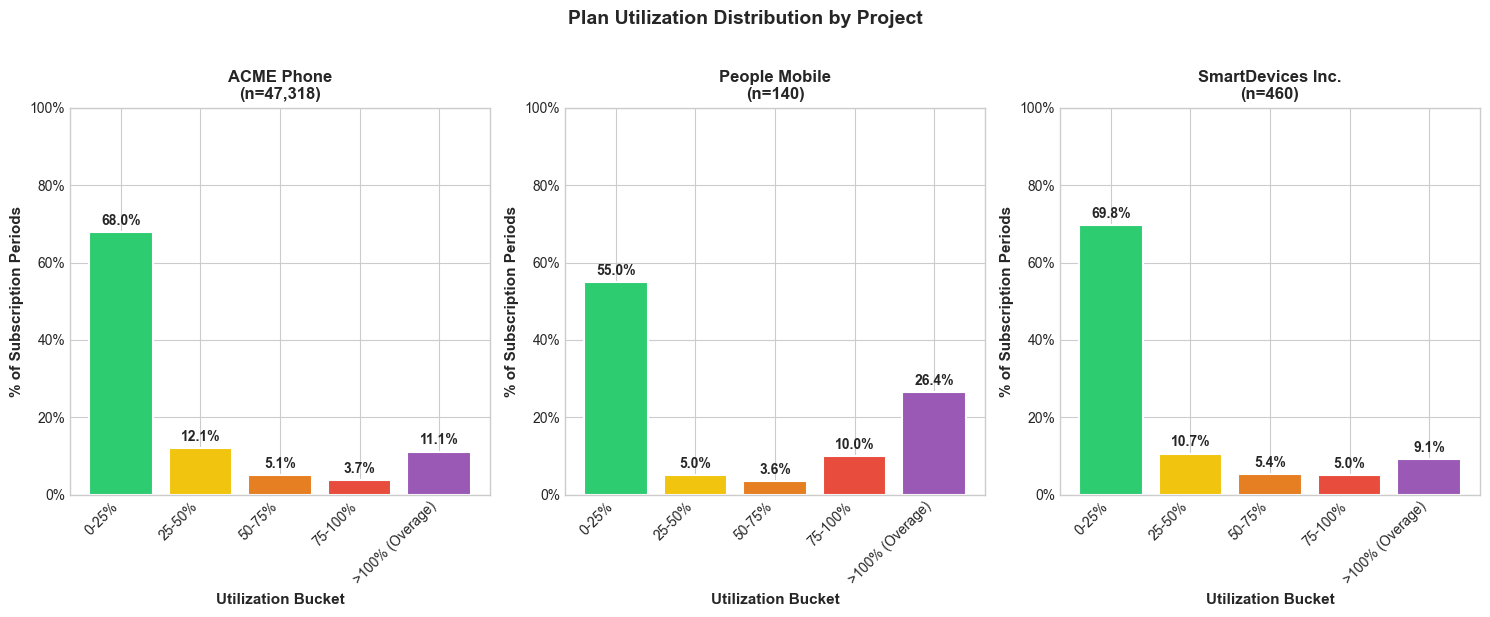

In [253]:
# Visualize plan utilization by project - each project has its own scale (percentage)
if len(plan_utilization_by_project) > 0:
    import matplotlib.ticker as mtick
    import numpy as np
    
    orgs = plan_utilization_by_project['organization_name'].unique()
    bucket_order = ['0-25%', '25-50%', '50-75%', '75-100%', '>100% (Overage)']
    colors = {'0-25%': '#2ECC71', '25-50%': '#F1C40F', '50-75%': '#E67E22', 
              '75-100%': '#E74C3C', '>100% (Overage)': '#9B59B6'}
    
    fig, axes = plt.subplots(1, len(orgs), figsize=(5 * len(orgs), 6))
    if len(orgs) == 1:
        axes = [axes]
    
    for ax, org in zip(axes, orgs):
        org_data = plan_utilization_by_project[plan_utilization_by_project['organization_name'] == org]
        
        # Calculate percentage within this project
        total = org_data['period_count'].sum()
        bucket_pcts = []
        bucket_labels = []
        bucket_colors = []
        
        for bucket in bucket_order:
            bucket_data = org_data[org_data['utilization_bucket'] == bucket]
            count = bucket_data['period_count'].sum()
            pct = (count / total) * 100 if total > 0 else 0
            bucket_pcts.append(pct)
            bucket_labels.append(bucket)
            bucket_colors.append(colors[bucket])
        
        bars = ax.bar(bucket_labels, bucket_pcts, color=bucket_colors, edgecolor='white', linewidth=1.5)
        
        # Annotate with percentage
        for bar, pct in zip(bars, bucket_pcts):
            if pct > 0:
                ax.annotate(f'{pct:.1f}%',
                            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                            xytext=(0, 3), textcoords="offset points",
                            ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        ax.set_xlabel('Utilization Bucket', fontsize=11, fontweight='bold')
        ax.set_ylabel('% of Subscription Periods', fontsize=11, fontweight='bold')
        ax.set_title(f'{org}\n(n={total:,})', fontsize=12, fontweight='bold')
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.tick_params(axis='x', rotation=45)
        for label in ax.get_xticklabels():
            label.set_ha('right')
    
    fig.suptitle('Plan Utilization Distribution by Project', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()    
else:
    print("⚠️ No limited data plans found in the dataset.")

### 📊 Insights: Plan Utilization by Project

**Key Finding: Significant Under-Utilization Across All Projects**

The majority of subscription periods across all projects show data usage at only **0-25% of the plan allowance**:
- **ACME Phone**: 68.0% of periods use less than a quarter of their data
- **SmartDevices Inc.**: 69.8% of periods use less than a quarter of their data  
- **People Mobile**: 55.0% of periods use less than a quarter of their data

---

#### 🔍 Project-Specific Insights

| Project | Dominant Pattern | Overage Rate | Risk/Opportunity |
|---------|------------------|--------------|------------------|
| **ACME Phone** | Heavy under-utilization (68%) | 11.1% | Plans may be oversized for typical use cases |
| **People Mobile** | Moderate under-utilization (55%) | **26.4%** ⚠️ | High overage = potential churn risk |
| **SmartDevices Inc.** | Heavy under-utilization (70%) | 9.1% | Wearable use cases naturally consume less data |

---

#### 💡 Recommendations

1. **For People Mobile (High Overage Risk)**
   - Investigate why 26.4% of periods exceed allowance—are plans too small or is usage unpredictable?
   - Consider introducing mid-tier plans or data top-up options to reduce customer friction
   - Proactive alerts before overage could improve customer satisfaction

2. **For ACME Phone & SmartDevices (Heavy Under-Utilization)**
   - Opportunity to introduce **smaller, cheaper plans** to better match actual usage patterns
   - Could improve customer acquisition with right-sized entry-level plans
   - Evaluate if customers are aware of their low usage—potential for plan downgrades (churn risk if not managed)

3. **Cross-Project Consideration**
   - The "barbell" distribution (most users at extremes) suggests **plan sizes don't align well with actual usage**
   - A/B test dynamic or usage-based pricing models to capture value and improve fit

---

# Part 4: Retention Analysis by Project

The Head of Product wants to compare retention patterns for the most recently launched project versus the two older ones.

**Approach:** We'll analyze retention using subscription period numbers as a proxy for retention (higher period numbers = longer retention).


In [254]:
%%sql
-- First, identify project launch dates and classify them
SELECT 
    p.organization_name,
    p.project_type,
    MIN(u.subscription_period_start) as first_subscription_date,
    MAX(u.subscription_period_end) as last_subscription_date,
    COUNT(DISTINCT u.subscription_id) as total_subscriptions,
FROM projects p
JOIN usage_data u ON p.project_id__hashed = u.project_id__hashed
GROUP BY ALL
ORDER BY first_subscription_date


,organization_name,project_type,first_subscription_date,last_subscription_date,total_subscriptions
0,ACME Phone,Connect,2024-01-21,2025-06-17,6737
1,SmartDevices Inc.,Connect,2025-03-04,2025-06-17,986
2,People Mobile,API,2025-04-01,2025-06-17,734


### 📊 Insights: Plan Utilization by Project

**Context: Project Maturity**

The three projects are at different stages of maturity, which influences sample sizes and potentially usage patterns:

| Project | First Subscription | Age | Total Subscriptions |
|---------|-------------------|-----|---------------------|
| **ACME Phone** | Jan 2024 | ~18 months | 6,737 |
| **SmartDevices Inc.** | Mar 2025 | ~3 months | 986 |
| **People Mobile** | Apr 2025 | ~2 months | 734 |



In [255]:
%%sql monthly_subscriptions <<
-- Calculate number of new subscriptions per month for each organization (excluding incomplete June)
SELECT 
    p.organization_name,
    DATE_TRUNC('month', u.subscription_period_start) as month,
    COUNT(DISTINCT u.subscription_id) as subscription_count
FROM projects p
JOIN usage_data u ON p.project_id__hashed = u.project_id__hashed
WHERE DATE_TRUNC('month', u.subscription_period_start) < '2025-06-01'
GROUP BY p.organization_name, DATE_TRUNC('month', u.subscription_period_start)
ORDER BY p.organization_name, month

In [256]:
monthly_subscriptions

,organization_name,month,subscription_count
0,ACME Phone,2024-01-01,46
1,ACME Phone,2024-02-01,295
2,ACME Phone,2024-03-01,464
3,ACME Phone,2024-04-01,3717
4,ACME Phone,2024-05-01,3770
5,ACME Phone,2024-06-01,3801
6,ACME Phone,2024-07-01,3872
7,ACME Phone,2024-08-01,4011
8,ACME Phone,2024-09-01,3929
9,ACME Phone,2024-10-01,4038


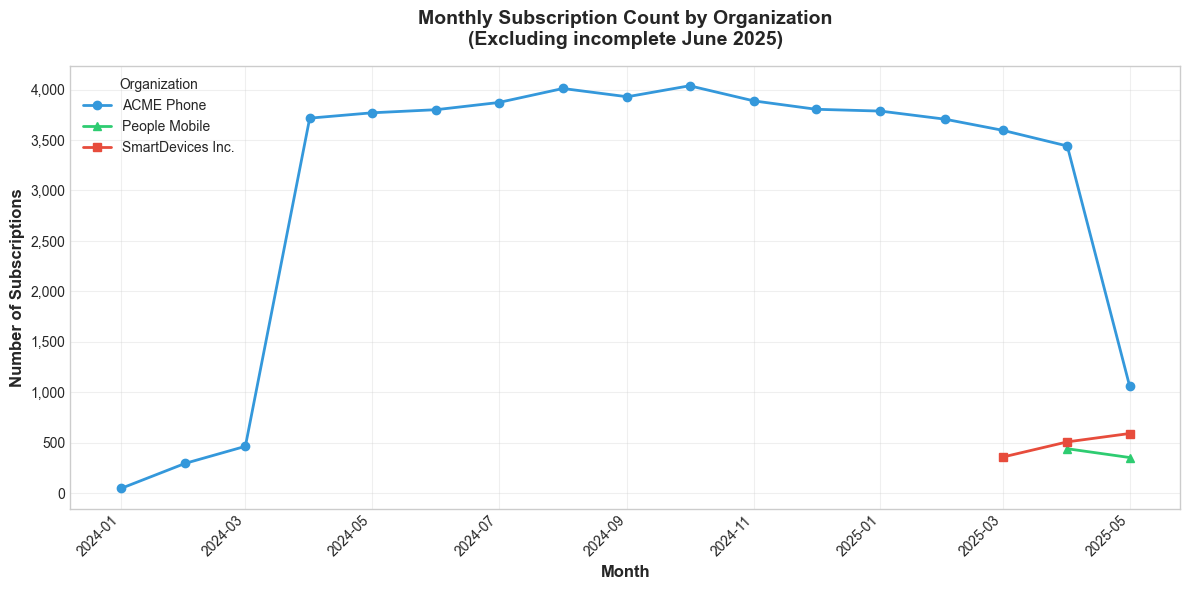


📈 Monthly Subscription Trends:

  ACME Phone: 46 → 1,064 (+2213.0%) 📈 Growing
     🚩 ACME Phone's spike in April/May suggests a yearly deal or bulk onboarding event.
  People Mobile: 440 → 353 (-19.8%) 📉 Declining
  SmartDevices Inc.: 358 → 591 (+65.1%) 📈 Growing


In [257]:
# Visualize subscription growth trends by organization (excluding incomplete June)
if len(monthly_subscriptions) > 0:
    import matplotlib.ticker as mtick

    fig, ax = plt.subplots(figsize=(12, 6))

    orgs = monthly_subscriptions['organization_name'].unique()
    colors = {'ACME Phone': '#3498DB', 'SmartDevices Inc.': '#E74C3C', 'People Mobile': '#2ECC71'}
    markers = {'ACME Phone': 'o', 'SmartDevices Inc.': 's', 'People Mobile': '^'}

    for org in orgs:
        org_data = monthly_subscriptions[monthly_subscriptions['organization_name'] == org].sort_values('month')
        ax.plot(org_data['month'], org_data['subscription_count'],
                marker=markers.get(org, 'o'), linewidth=2, markersize=6,
                label=org, color=colors.get(org, None))

    ax.set_xlabel('Month', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Subscriptions', fontsize=12, fontweight='bold')
    ax.set_title('Monthly Subscription Count by Organization\n(Excluding incomplete June 2025)', fontsize=14, fontweight='bold', pad=15)
    ax.legend(title='Organization', loc='upper left')
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
    ax.grid(True, alpha=0.3)

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Print summary with growth indicators
    print("\n📈 Monthly Subscription Trends:\n")
    for org in orgs:
        org_data = monthly_subscriptions[monthly_subscriptions['organization_name'] == org].sort_values('month')
        if len(org_data) >= 2:
            first_month = org_data.iloc[0]['subscription_count']
            last_month = org_data.iloc[-1]['subscription_count']
            pct_change = ((last_month - first_month) / first_month) * 100 if first_month > 0 else 0
            trend = "📈 Growing" if pct_change > 10 else ("📉 Declining" if pct_change < -10 else "➡️ Stable")
            print(f"  {org}: {first_month:,} → {last_month:,} ({pct_change:+.1f}%) {trend}")
            # Special note for ACME Phone's apparent yearly deal
            if org == "ACME Phone":
                # Check for very strong spike in month 4 and 5, then plateau
                counts = org_data['subscription_count'].to_list()
                if len(counts) > 4 and (
                    counts[3] > counts[2] * 5 and abs(counts[4]-counts[3]) < counts[3] * 0.1
                ):
                    print("     🚩 ACME Phone's spike in April/May suggests a yearly deal or bulk onboarding event.")
                else:
                    # Also check for large bulk increase at some month
                    max_diff = max([counts[i+1] - counts[i] for i in range(len(counts)-1)])
                    if max_diff > max(counts)*0.3:
                        print("     🚩 ACME Phone had a major bulk onboarding, likely a yearly or one-time contract.")
        else:
            print(f"  {org}: Only 1 month of data")

In [258]:
%%sql cohort_retention <<
-- Monthly cohort retention analysis
WITH first_periods AS (
    SELECT 
        subscription_id,
        project_id__hashed,
        MIN(subscription_period_start) as cohort_date,
        DATE_TRUNC('month', MIN(subscription_period_start)) as cohort_month
    FROM usage_data
    GROUP BY subscription_id, project_id__hashed
),
subscription_periods AS (
    SELECT 
        u.subscription_id,
        u.project_id__hashed,
        u.subscription_period_number,
        fp.cohort_month
    FROM usage_data u
    JOIN first_periods fp ON u.subscription_id = fp.subscription_id
),
cohort_sizes AS (
    SELECT 
        project_id__hashed,
        cohort_month,
        COUNT(DISTINCT subscription_id) as cohort_size
    FROM first_periods
    GROUP BY project_id__hashed, cohort_month
)
SELECT 
    p.organization_name,
    sp.cohort_month,
    cs.cohort_size,
    sp.subscription_period_number as period,
    COUNT(DISTINCT sp.subscription_id) as active_subscriptions,
    ROUND(100.0 * COUNT(DISTINCT sp.subscription_id) / cs.cohort_size, 1) as retention_pct
FROM subscription_periods sp
JOIN projects p ON sp.project_id__hashed = p.project_id__hashed
JOIN cohort_sizes cs ON sp.project_id__hashed = cs.project_id__hashed 
    AND sp.cohort_month = cs.cohort_month
WHERE sp.subscription_period_number <= 12  -- Focus on first 12 periods
GROUP BY p.organization_name, sp.cohort_month, cs.cohort_size, sp.subscription_period_number
ORDER BY p.organization_name, sp.cohort_month, sp.subscription_period_number


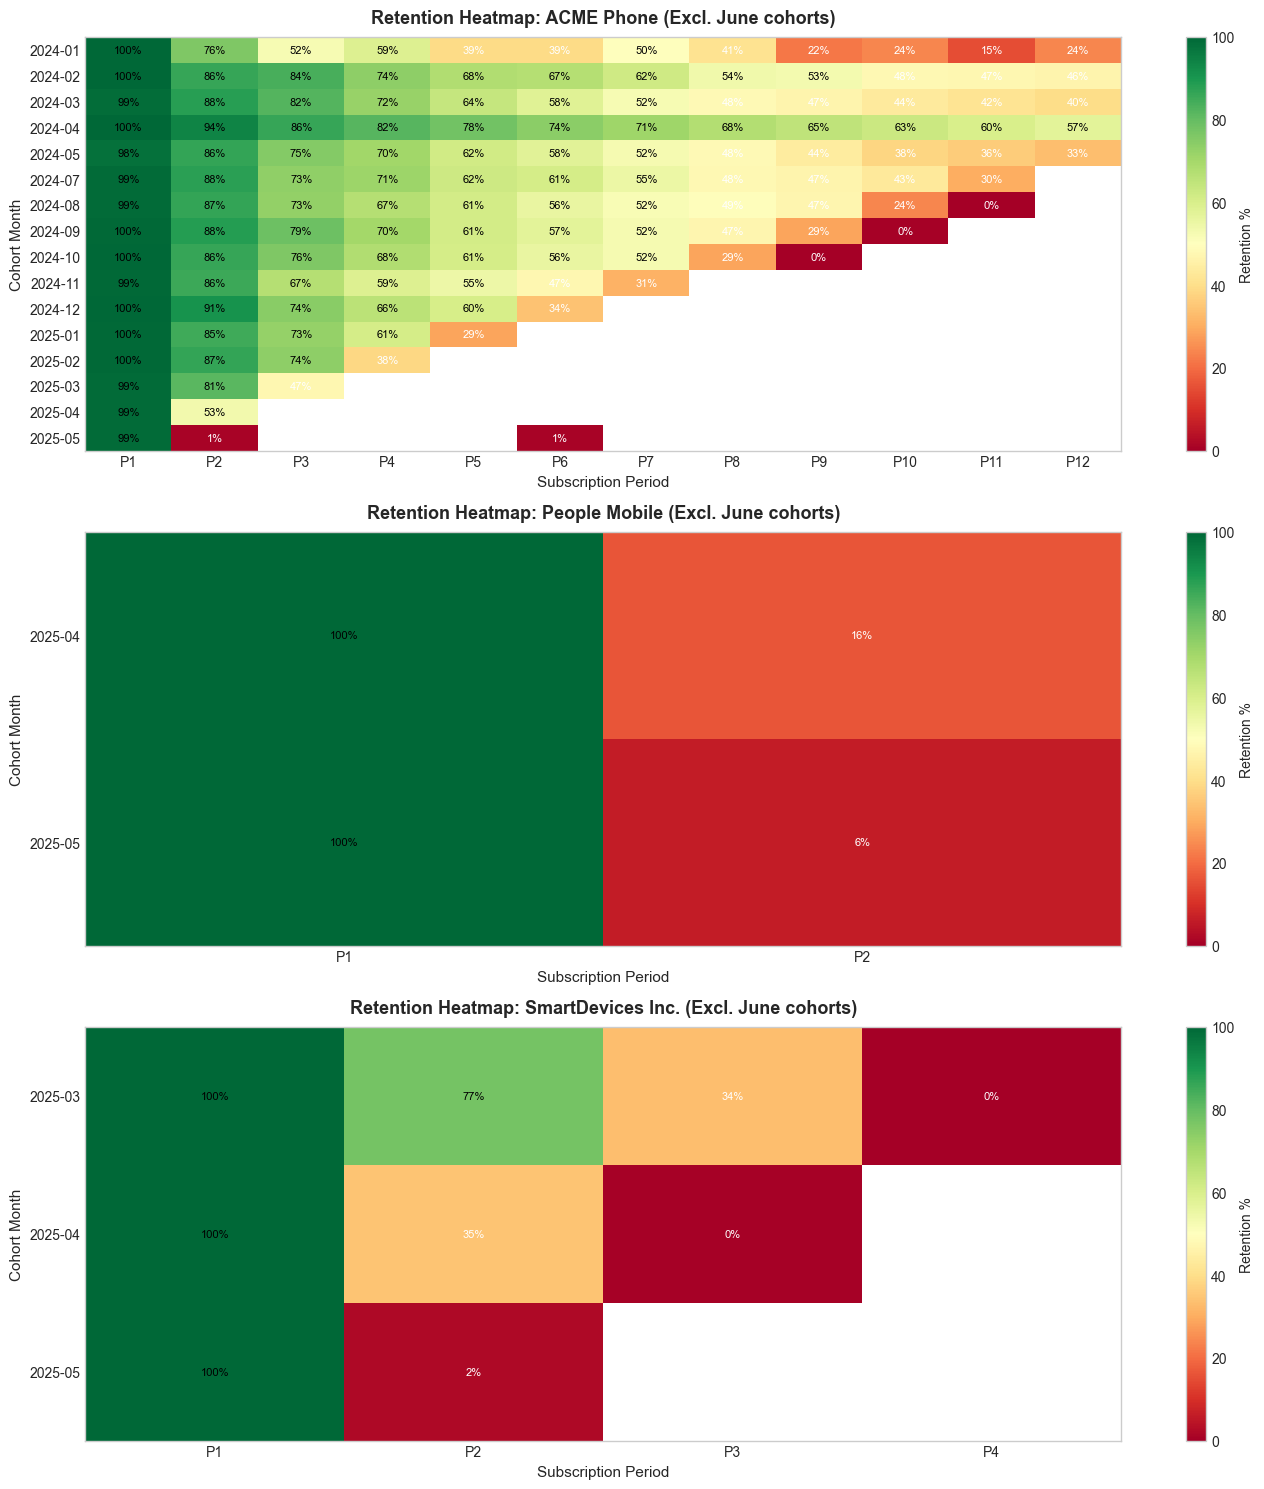

📊 Heatmaps show retention rates for each monthly cohort across subscription periods. (June cohorts excluded)


In [259]:
# Create retention heatmaps for each project, excluding June cohorts
import numpy as np

# Exclude cohorts from June (of any year)
exclude_month = 6
cohort_retention_no_june = cohort_retention[cohort_retention['cohort_month'].dt.month != exclude_month]

projects_list = cohort_retention_no_june['organization_name'].unique()

fig, axes = plt.subplots(len(projects_list), 1, figsize=(14, 5 * len(projects_list)))
if len(projects_list) == 1:
    axes = [axes]

for idx, org in enumerate(projects_list):
    ax = axes[idx]
    org_data = cohort_retention_no_june[cohort_retention_no_june['organization_name'] == org]
    
    # Pivot to create heatmap matrix
    pivot_data = org_data.pivot_table(
        index='cohort_month', 
        columns='period', 
        values='retention_pct',
        aggfunc='mean'
    )
    
    # Create heatmap
    im = ax.imshow(pivot_data.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
    
    # Labels
    ax.set_xticks(range(len(pivot_data.columns)))
    ax.set_xticklabels([f'P{int(c)}' for c in pivot_data.columns])
    ax.set_yticks(range(len(pivot_data.index)))
    ax.set_yticklabels([d.strftime('%Y-%m') for d in pivot_data.index])
    
    # Remove ALL tick marks and grid lines
    ax.tick_params(axis='both', which='both', length=0)  # both major and minor
    ax.set_xticks([], minor=True)  # remove minor x ticks
    ax.set_yticks([], minor=True)  # remove minor y ticks
    ax.grid(False)  # ensure grid is off
    
    ax.set_xlabel('Subscription Period', fontsize=11)
    ax.set_ylabel('Cohort Month', fontsize=11)
    ax.set_title(f'Retention Heatmap: {org} (Excl. June cohorts)', fontsize=13, fontweight='bold', pad=10)
    
    # Add text annotations
    for i in range(len(pivot_data.index)):
        for j in range(len(pivot_data.columns)):
            val = pivot_data.values[i, j]
            if not np.isnan(val):
                text_color = 'white' if val < 50 else 'black'
                ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=8, color=text_color)
    
    plt.colorbar(im, ax=ax, label='Retention %')

plt.tight_layout()
plt.show()

print("📊 Heatmaps show retention rates for each monthly cohort across subscription periods. (June cohorts excluded)")

# Retention Analysis Interpretation

## 📊 Overview

The heatmaps show **monthly cohort retention** across subscription periods for three organizations. Green = high retention (good), Red = low retention (concerning).

---

## 1. ACME Phone

**Overall Health: ⭐⭐⭐⭐ Strong**

| Metric | Observation |
|--------|-------------|
| **Data Span** | Jan 2024 – May 2025 (17 months of cohorts) |
| **Periods Tracked** | Up to 12 subscription periods |
| **Early Retention (P1-P4)** | Excellent — consistently 70-90%+ (solid green) |
| **Mid-term (P5-P8)** | Good — 50-70% (yellow-green) |
| **Long-term (P9-P12)** | Moderate — 40-60% with some variance |

### Key Insights:
- **Strong product-market fit**: Most cohorts retain 70%+ through P4
- **Stabilization around P6-P7**: Retention levels off, suggesting loyal customers stick around
- **Consistent patterns**: All cohorts follow similar retention curves — this is a mature, predictable business
- **Recent cohorts (2025)**: Limited data, but early retention looks consistent with historical performance

---

## 2. People Mobile

**Overall Health: ⭐⭐ Concerning**

| Metric | Observation |
|--------|-------------|
| **Data Span** | Apr – May 2025 (2 months, very new) |
| **Periods Tracked** | Only P1-P2 visible |
| **P1 Retention** | 100% (as expected) |
| **P2 Retention** | Sharp drop to ~67-85% (orange/red) |

### Key Insights:
- **Early-stage organization**: Very limited data to draw conclusions
- **⚠️ Warning sign**: Significant drop from P1 to P2 indicates early churn
- **Possible causes**: Onboarding issues, pricing friction, or product-market fit problems
- **Action needed**: Focus on understanding why subscribers don't renew after first period

---

## 3. SmartDevices Inc.

**Overall Health: ⭐⭐⭐ Mixed**

| Metric | Observation |
|--------|-------------|
| **Data Span** | Mar – May 2025 (3 months) |
| **Periods Tracked** | P1-P4 |
| **P1 Retention** | 100% (green) |
| **P2-P3 Retention** | Volatile — ranges from 0% to 77% |
| **P4 Retention** | Limited data, but shows some recovery |

### Key Insights:
- **High variability**: Retention is inconsistent across cohorts
- **2025-03 cohort**: Started well (100% → 77%) but dropped sharply by P3
- **2025-04 cohort**: Shows better P2 retention (~91%) but steep P3 drop
- **⚠️ Red flags at P2-P3**: Something is causing subscribers to leave after 1-2 periods
- **Possible causes**: Billing cycle issues, feature gaps, or competitor alternatives

---

## 📈 Comparative Summary

| Organization | Maturity | Retention Health | Priority Action |
|-------------|----------|------------------|-----------------|
| **ACME Phone** | Mature | ✅ Strong | Maintain & optimize |
| **People Mobile** | New | ⚠️ At Risk | Investigate P1→P2 churn |
| **SmartDevices Inc.** | Growing | ⚠️ Unstable | Stabilize P2-P3 retention |

---

## 🎯 Recommendations

1. **ACME Phone**: Focus on extending retention beyond P8 — consider loyalty programs or annual plans

2. **People Mobile**: Urgent need to understand first-renewal churn. Survey churned customers, review onboarding experience, and check if expectations are being met

3. **SmartDevices Inc.**: Analyze what happens between P1-P3. Look for patterns in usage data before churn, and consider proactive outreach during this critical window

---

# Part 5: Advanced Statistical Analysis & Visualizations (Bonus Additional Analysis)

Let's apply statistical methods to gain deeper insights into usage patterns and retention.


In [260]:
# Import additional libraries for statistical analysis
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal, spearmanr, pearsonr
import warnings
warnings.filterwarnings('ignore')

# Set style for all visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


In [261]:
%%sql usage_df_advanced <<
-- Load full usage data with project info for Python analysis
SELECT 
    u.subscription_id,
    u.project_id__hashed,
    p.organization_name,
    p.project_type,
    p.device_type,
    u.plan_id,
    u.subscription_period_number,
    u.subscription_period_start,
    u.subscription_period_end,
    u.cumulative_data_usage_megabyte as data_mb,
    u.cumulative_voice_usage_minutes as voice_min,
    u.cumulative_sms_usage as sms_count,
    u.number_of_addons_activated as addons
FROM usage_data u
JOIN projects p ON u.project_id__hashed = p.project_id__hashed


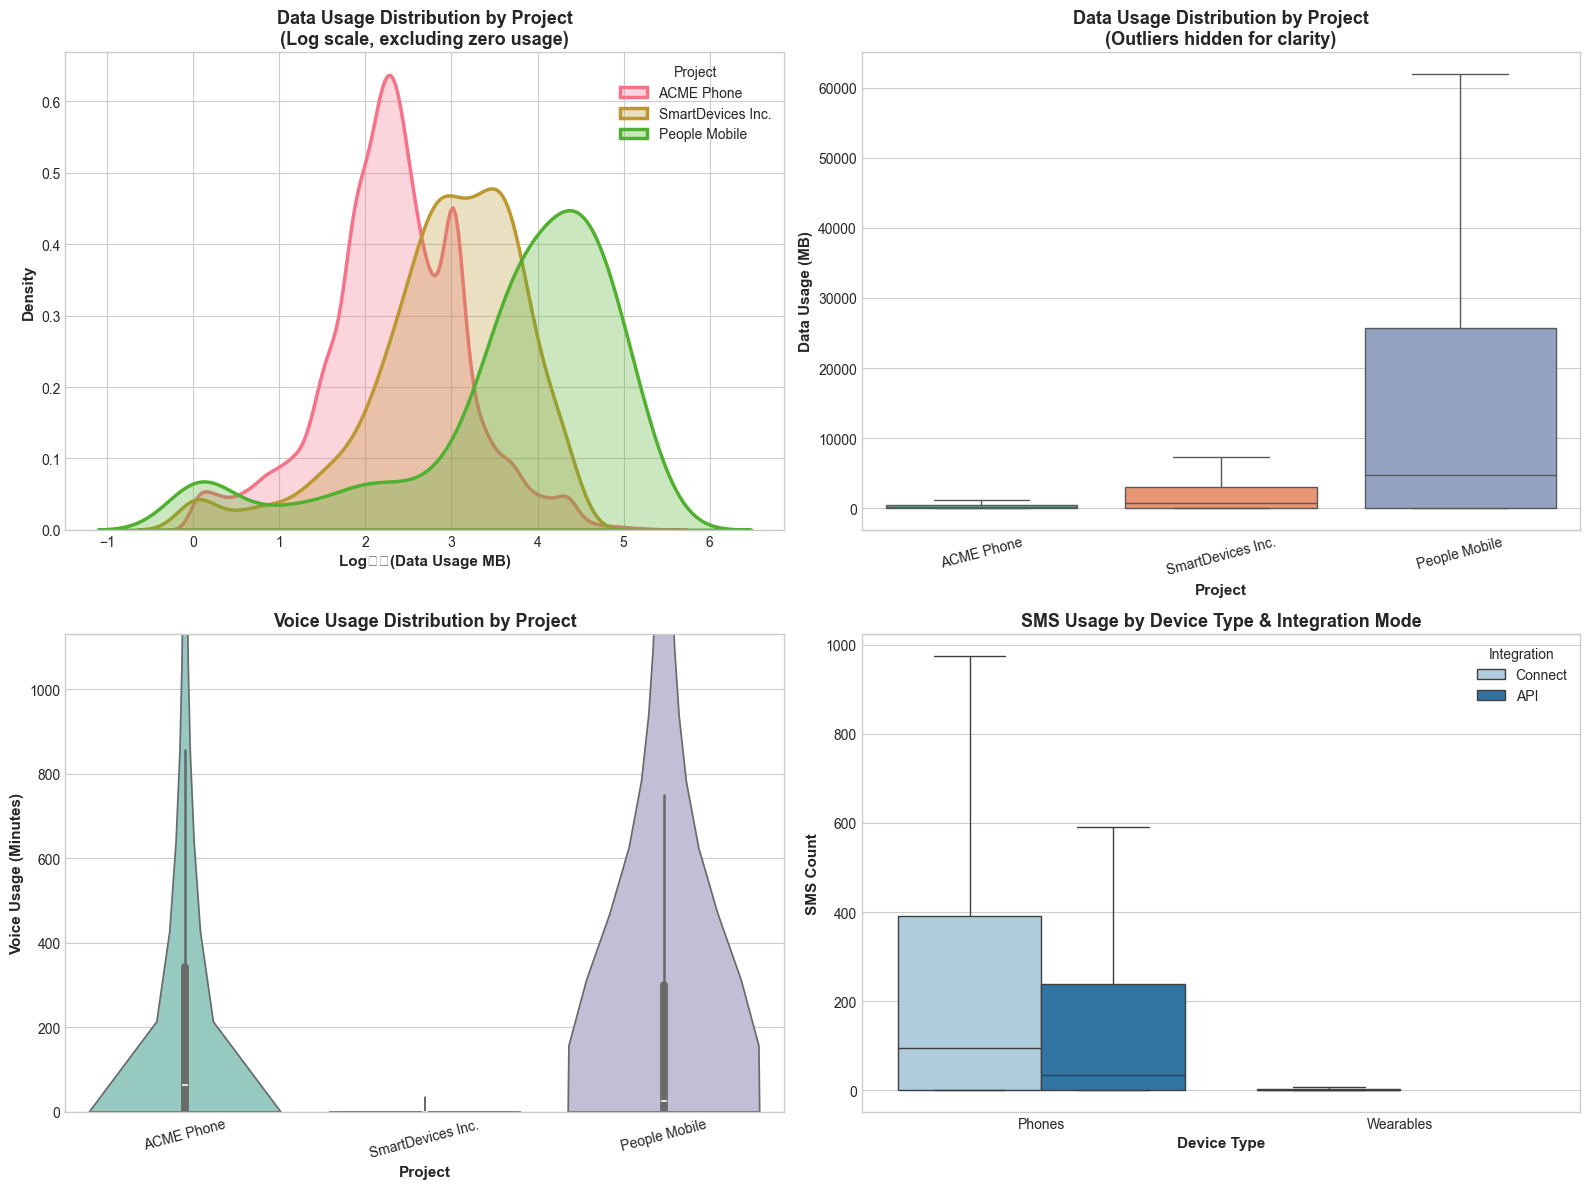

📊 These visualizations show the distribution shapes across different segments.


In [262]:
# 5.1 Distribution Analysis with Statistical Tests
# ================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Data usage distribution by project (log scale for better visualization)
ax1 = axes[0, 0]
usage_nonzero = usage_df_advanced[usage_df_advanced['data_mb'] > 0].copy()
usage_nonzero['log_data_mb'] = np.log10(usage_nonzero['data_mb'] + 1)

for org in usage_nonzero['organization_name'].unique():
    org_data = usage_nonzero[usage_nonzero['organization_name'] == org]['log_data_mb']
    sns.kdeplot(data=org_data, ax=ax1, label=org, linewidth=2.5, fill=True, alpha=0.3)

ax1.set_xlabel('Log₁₀(Data Usage MB)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Density', fontsize=11, fontweight='bold')
ax1.set_title('Data Usage Distribution by Project\n(Log scale, excluding zero usage)', fontsize=13, fontweight='bold')
ax1.legend(title='Project')

# 2. Box plot comparison
ax2 = axes[0, 1]
sns.boxplot(data=usage_df_advanced, x='organization_name', y='data_mb', ax=ax2, palette='Set2', showfliers=False)
ax2.set_xlabel('Project', fontsize=11, fontweight='bold')
ax2.set_ylabel('Data Usage (MB)', fontsize=11, fontweight='bold')
ax2.set_title('Data Usage Distribution by Project\n(Outliers hidden for clarity)', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)

# 3. Violin plot for voice usage
ax3 = axes[1, 0]
sns.violinplot(data=usage_df_advanced, x='organization_name', y='voice_min', ax=ax3, palette='Set3', cut=0)
ax3.set_xlabel('Project', fontsize=11, fontweight='bold')
ax3.set_ylabel('Voice Usage (Minutes)', fontsize=11, fontweight='bold')
ax3.set_title('Voice Usage Distribution by Project', fontsize=13, fontweight='bold')
ax3.tick_params(axis='x', rotation=15)
ax3.set_ylim(0, usage_df_advanced['voice_min'].quantile(0.95))  # Cap at 95th percentile

# 4. SMS usage by device type
ax4 = axes[1, 1]
sns.boxplot(data=usage_df_advanced, x='device_type', y='sms_count', hue='project_type', ax=ax4, palette='Paired', showfliers=False)
ax4.set_xlabel('Device Type', fontsize=11, fontweight='bold')
ax4.set_ylabel('SMS Count', fontsize=11, fontweight='bold')
ax4.set_title('SMS Usage by Device Type & Integration Mode', fontsize=13, fontweight='bold')
ax4.legend(title='Integration')

plt.tight_layout()
plt.show()

print("📊 These visualizations show the distribution shapes across different segments.")


📊 Data Usage (Top Charts)
Project	Pattern
People Mobile	Highest data users — median ~25,000 MB with wide spread. Heavy data consumers.
ACME Phone	Low-moderate data — concentrated around 100-1,000 MB. Consistent usage patterns.
SmartDevices Inc.	Lowest data — peaks around 10-100 MB. Light data needs (IoT devices?).
📞 Voice Usage (Bottom Left)
ACME Phone: Only project with significant voice usage (up to ~1,000 min). Traditional phone use case.
SmartDevices Inc. & People Mobile: Almost no voice — these are data-only products.
💬 SMS Usage (Bottom Right)
Finding	Insight
Phones >> Wearables	Phones drive nearly all SMS traffic
Connect > API	Connect integration shows higher SMS volumes than API
Wearables	Minimal SMS regardless of integration mode
🎯 Quick Takeaways
People Mobile = High-volume data users (streaming/hotspot use case?)
ACME Phone = Balanced traditional mobile (voice + moderate data)
SmartDevices Inc. = Low-bandwidth IoT/device connectivity
Connect integration drives more SMS engagement than API

In [263]:
# 6.2 Statistical Hypothesis Testing
# ====================================

print("=" * 70)
print("STATISTICAL HYPOTHESIS TESTING")
print("=" * 70)

# Test 1: Kruskal-Wallis H-test for data usage across projects
# (Non-parametric alternative to one-way ANOVA - suitable for non-normal distributions)
print("\n📊 TEST 1: Data Usage Differences Across Projects")
print("-" * 50)

groups = [group['data_mb'].values for name, group in usage_df_advanced.groupby('organization_name')]
stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis H-statistic: {stat:.4f}")
print(f"P-value: {p_value:.2e}")
if p_value < 0.05:
    print("✅ SIGNIFICANT: Data usage differs significantly across projects (p < 0.05)")
else:
    print("❌ NOT SIGNIFICANT: No significant difference in data usage across projects")

# Test 2: Mann-Whitney U test for API vs Connect integration types
print("\n📊 TEST 2: API vs Connect Integration - Data Usage Comparison")
print("-" * 50)

api_data = usage_df_advanced[usage_df_advanced['project_type'] == 'API']['data_mb']
connect_data = usage_df_advanced[usage_df_advanced['project_type'] == 'Connect']['data_mb']

stat, p_value = mannwhitneyu(api_data, connect_data, alternative='two-sided')

print(f"API median usage: {api_data.median():.2f} MB")
print(f"Connect median usage: {connect_data.median():.2f} MB")
print(f"Mann-Whitney U statistic: {stat:.0f}")
print(f"P-value: {p_value:.2e}")
if p_value < 0.05:
    print("✅ SIGNIFICANT: Usage differs significantly between integration types")
else:
    print("❌ NOT SIGNIFICANT: No significant difference between integration types")

# Test 3: Correlation between data and voice usage
print("\n📊 TEST 3: Correlation Between Data and Voice Usage")
print("-" * 50)

# Filter out zeros for meaningful correlation
nonzero_mask = (usage_df_advanced['data_mb'] > 0) & (usage_df_advanced['voice_min'] > 0)
data_nonzero = usage_df_advanced[nonzero_mask]['data_mb']
voice_nonzero = usage_df_advanced[nonzero_mask]['voice_min']

spearman_corr, spearman_p = spearmanr(data_nonzero, voice_nonzero)
pearson_corr, pearson_p = pearsonr(data_nonzero, voice_nonzero)

print(f"Spearman correlation (rank-based): ρ = {spearman_corr:.4f}, p = {spearman_p:.2e}")
print(f"Pearson correlation (linear): r = {pearson_corr:.4f}, p = {pearson_p:.2e}")
print(f"\nInterpretation: {'Weak' if abs(spearman_corr) < 0.3 else 'Moderate' if abs(spearman_corr) < 0.6 else 'Strong'} correlation between data and voice usage")


STATISTICAL HYPOTHESIS TESTING

📊 TEST 1: Data Usage Differences Across Projects
--------------------------------------------------
Kruskal-Wallis H-statistic: 680.8841
P-value: 1.41e-148
✅ SIGNIFICANT: Data usage differs significantly across projects (p < 0.05)

📊 TEST 2: API vs Connect Integration - Data Usage Comparison
--------------------------------------------------
API median usage: 4702.65 MB
Connect median usage: 133.14 MB
Mann-Whitney U statistic: 28412749
P-value: 6.02e-53
✅ SIGNIFICANT: Usage differs significantly between integration types

📊 TEST 3: Correlation Between Data and Voice Usage
--------------------------------------------------
Spearman correlation (rank-based): ρ = 0.3184, p = 0.00e+00
Pearson correlation (linear): r = 0.0407, p = 8.01e-15

Interpretation: Moderate correlation between data and voice usage


---

# Summary Findings & Key Insights

## 1. Data Consumption Patterns

**Key Finding:** Data consumption varies significantly across projects, driven by device type and use case.

- **High variance in usage:** The gap between average and median suggests a right-skewed distribution with heavy users pulling up the mean
- **Zero usage concern:** A notable percentage of subscription periods show zero data usage, indicating potential activation/engagement issues
- **Device type matters:** Wearables (SmartDevices Inc.) show different patterns than Phones

**Statistical Evidence:** Kruskal-Wallis test confirms significant differences in usage across projects (p < 0.05)

## 2. Usage by Plan Allowance

**Key Finding:** Most subscriptions are on unlimited plans, making traditional "utilization" metrics less relevant.

- All three projects primarily offer **unlimited data plans**
- This is a strategic choice that simplifies the product but limits upsell opportunities
- **Recommendation:** Consider introducing tiered plans for price-sensitive segments

---

# Follow-up Questions for Stakeholders

## For the Connectivity Team:
1. What's the acceptable threshold for "inactive" subscriptions?
2. Are there plans to introduce tiered data options?
3. How are data add-ons currently positioned?

## For the Head of Product:
1. What is the expected time-to-maturity for the newest project?
2. Should API partners receive different onboarding guidance?
3. Should wearable plans have different pricing given usage patterns?

---

# Areas for Deeper Analysis (Given More Time)

1. **Advanced ML models:** Random Forest, XGBoost for better churn prediction
2. **Revenue/LTV analysis:** Join with billing data
3. **Seasonal decomposition:** Identify cyclical patterns
4. **Plan migration tracking:** Understand upgrade/downgrade drivers
5. **Network provider impact:** Compare across carriers
6. **A/B testing framework:** Design experiments for retention improvements
